<div align="center">

## **DS108 - TIỀN XỬ LÝ VÀ XÂY DỰNG BỘ DỮ LIỆU**

## **ĐỒ ÁN - THU THẬP & TIỀN XỬ LÝ DỮ LIỆU TÀI CHÍNH DOANH NGHIỆP CHO DỰ ĐOÁN LỢI NHUẬN**
</div>

**GVHD:** TS.Nguyễn Gia Tuấn Anh - CN: Trần Quốc Khánh

**Sinh viên thực hiện:**

| Họ và tên | MSSV |
|---|---|
| Võ Hạnh Nguyên | 24521218 |
| Phan Thị Ánh Nguyệt | 24521221 |

**Notebook:** `03_exploratory_data_analysis.ipynb` — EDA trước và sau xử lí

---

### **Mục tiêu**
Notebook này thực hiện Exploratory Data Analysis (EDA) trên dữ liệu tài chính doanh nghiệp trước và sau tiền xử lý nhằm:
- Hiểu đặc điểm dữ liệu,
- Phát hiện các vấn đề kỹ thuật,
- Rút ra business insights,
- Đánh giá hiệu quả preprocessing pipeline trước khi xây dựng mô hình học máy.
---

### ***Pipeline:***

1. Import thư viện
2. Sector Mapping
3. Đọc dữ liệu
4. EDA - Trước xử lý (Data_DS108_raw.csv)
5. EDA - Sau xử lý (Data_DS108_processed.csv)

---

## **1. Import thư viện**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import logging
from pathlib import Path
from typing import Dict, List
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
from IPython.display import display
from scipy.stats import gaussian_kde
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore")

for h in logging.root.handlers[:]:
    logging.root.removeHandler(h)
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(message)s",
                    datefmt="%H:%M:%S")
logger = logging.getLogger("DS108")

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")
sns.set_palette("husl")

# ── Paths ────────────────────────────────────────────────────
PROJECT_ROOT   = Path.cwd().parent
RAW_PATH       = PROJECT_ROOT / "data/raw/Data_DS108_raw.csv"
PROCESSED_PATH = PROJECT_ROOT / "data/processed/Data_DS108_processed.csv"

# ── Constants (giữ nguyên tên để EDA cells dùng được) ────────
GROUP_COL   = "symbol"
DATE_COL_RAW    = "fiscalDateEnding"
DATE_COL_PROCESSED = "fiscaldateending"
TARGET_REG  = "next_quarter_net_income"
TARGET_CLS  = "profit_increase_next"
TRAIN_CUTOFF = 2021

print("Đã import các thư viện và thiết lập cấu hình cơ bản.")


Đã import các thư viện và thiết lập cấu hình cơ bản.


## **2. Sector Mapping**


In [3]:
SYMBOL_SECTOR_MAP: Dict[str, str] = {
    # Technology
    'AAPL' : 'Technology',
    'MSFT' : 'Technology',
    'NVDA' : 'Technology',
    'AVGO' : 'Technology',
    'ORCL' : 'Technology',
    'TSM'  : 'Technology',
    'PLTR' : 'Technology',

    # Communication Services
    'META' : 'Communication Services',
    'GOOG' : 'Communication Services',
    'NFLX' : 'Communication Services',

    # Consumer Discretionary
    'AMZN' : 'Consumer Discretionary',
    'TSLA' : 'Consumer Discretionary',
    'HD'   : 'Consumer Discretionary',
    'BABA' : 'Consumer Discretionary',

    # Consumer Staples
    'COST' : 'Consumer Staples',
    'WMT'  : 'Consumer Staples',

    # Financials
    'JPM'  : 'Financials',
    'MA'   : 'Financials',
    'V'    : 'Financials',
    'BRK-B': 'Financials',

    # Healthcare
    'JNJ'  : 'Healthcare',
    'LLY'  : 'Healthcare',

    # Energy
    'XOM'  : 'Energy',
}

logger.info('Sector map loaded: %d symbols across %d sectors',
            len(SYMBOL_SECTOR_MAP),
            len(set(SYMBOL_SECTOR_MAP.values())))


01:36:27 | INFO | Sector map loaded: 23 symbols across 7 sectors


---
## **3. Đọc dữ liệu**


In [4]:
# ── Đọc dữ liệu thô ─────────────────────────────────────────
df_raw = pd.read_csv(RAW_PATH)
df_raw[DATE_COL_RAW] = pd.to_datetime(df_raw[DATE_COL_RAW], errors="coerce")
print(f"df_raw  : {df_raw.shape}")

# ── Đọc dữ liệu đã xử lý ─────────────────────────────────────
df_processed = pd.read_csv(PROCESSED_PATH)
df_processed[DATE_COL_PROCESSED] = pd.to_datetime(df_processed[DATE_COL_PROCESSED], errors="coerce")
print(f"df_processed: {df_processed.shape}")

# Alias df_fe → các EDA cells gốc dùng tên df_fe
df_fe = df_processed.copy()

print("\nĐọc dữ liệu thành công!")
print(f"  Raw       : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")
print(f"  Processed : {df_processed.shape[0]:,} rows × {df_processed.shape[1]} cols")


df_raw  : (1762, 27)
df_processed: (1735, 117)

Đọc dữ liệu thành công!
  Raw       : 1,762 rows × 27 cols
  Processed : 1,735 rows × 117 cols


---
## **4. EDA — Trước xử lý (Data_DS108.csv)**


### **Overview tổng quát**


In [5]:
# ── Shape, dtypes, giá trị unique ───────────────────────────
print(f"- Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols")
print(f"\n- Kiểu dữ liệu:")
print(df_raw.dtypes.value_counts().to_string())

print(f"\n- Số công ty (symbol): {df_raw['symbol'].nunique()}")
print(f"  Symbols: {sorted(df_raw['symbol'].unique())}")

df_raw[DATE_COL_RAW] = pd.to_datetime(df_raw[DATE_COL_RAW], errors="coerce")
print(f"\n- Date range: {df_raw[DATE_COL_RAW].min().date()} → {df_raw[DATE_COL_RAW].max().date()}")

# Số quan sát mỗi công ty
print(f"\n- Số quarters mỗi công ty:")
display(df_raw.groupby("symbol").size().rename("n_quarters")
               .sort_values(ascending=False).to_frame().T)


- Shape: 1,762 rows × 27 cols

- Kiểu dữ liệu:
float64           24
str                2
datetime64[us]     1

- Số công ty (symbol): 23
  Symbols: ['AAPL', 'AMZN', 'AVGO', 'BABA', 'BRK-B', 'COST', 'GOOG', 'HD', 'JNJ', 'JPM', 'LLY', 'MA', 'META', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'PLTR', 'TSLA', 'TSM', 'V', 'WMT', 'XOM']

- Date range: 2006-01-31 → 2026-03-31

- Số quarters mỗi công ty:


symbol,AAPL,AMZN,BRK-B,GOOG,COST,JNJ,HD,XOM,ORCL,JPM,LLY,MA,MSFT,NFLX,NVDA,WMT,TSM,V,AVGO,TSLA,META,BABA,PLTR
n_quarters,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,81,80,77,74,65,60,29


### **4.1 Thống kê mô tả — Biến quy mô tuyệt đối**

Ngoài các thống kê cơ bản từ `.describe()` như mean, std hay quartiles, sử dụng thêm skewness và kurtosis để đánh giá đầy đủ hơn hình dạng phân phối dữ liệu. Hai chỉ số này phản ánh mức độ lệch và độ “đuôi nặng” của phân phối

- `|skew| > 1` → phân phối lệch mạnh → cần transform
- `kurtosis > 3` → đuôi nặng → có nhiều extreme values, cần xem xét winsorization


In [6]:
SCALE_COLS_RAW = [
    "totalrevenue", "grossprofit", "operatingincome",
    "netincome", "ebit", "ebitda",
    "costofrevenue", "operatingexpenses", "incomebeforetax",
    "incometaxexpense", "sellinggeneralandadministrative",
    "researchanddevelopment", "depreciationandamortization",
]
SCALE_COLS_RAW = [c for c in SCALE_COLS_RAW if c in df_raw.columns]

desc = df_raw[SCALE_COLS_RAW].describe().T
desc["skewness"] = df_raw[SCALE_COLS_RAW].skew()
desc["kurtosis"] = df_raw[SCALE_COLS_RAW].kurt()
desc["% negative"] = (df_raw[SCALE_COLS_RAW] < 0).mean() * 100
desc["% missing"] = df_raw[SCALE_COLS_RAW].isnull().mean() * 100

# Highlight skewness cao
def highlight_skew(val):
    if isinstance(val, float) and abs(val) > 3:
        return "background-color: #ffcccc"
    elif isinstance(val, float) and abs(val) > 1:
        return "background-color: #fff3cd"
    return ""

display(desc[["mean","std","min","25%","50%","75%","max",
              "skewness","kurtosis","% negative","% missing"]]
        .style.map(highlight_skew, subset=["skewness","kurtosis"])
        .format("{:.2f}"))


,mean,std,min,25%,50%,75%,max,skewness,kurtosis,% negative,% missing
ebit,12011335709.04,41005243054.85,-62074000000.00,972250000.00,3508000000.00,8051500000.00,657289000000.00,9.26,106.75,6.02,0.45
ebitda,16326339850.61,57374601655.11,-64540000000.00,1433000000.00,4675000000.00,10680000000.00,856233000000.00,9.04,100.03,4.20,0.96


### **4.2 Missing Value**

Kiểm tra **missing theo công ty nào** và **missing tập trung giai đoạn nào** để chọn chiến lược imputation phù hợp.


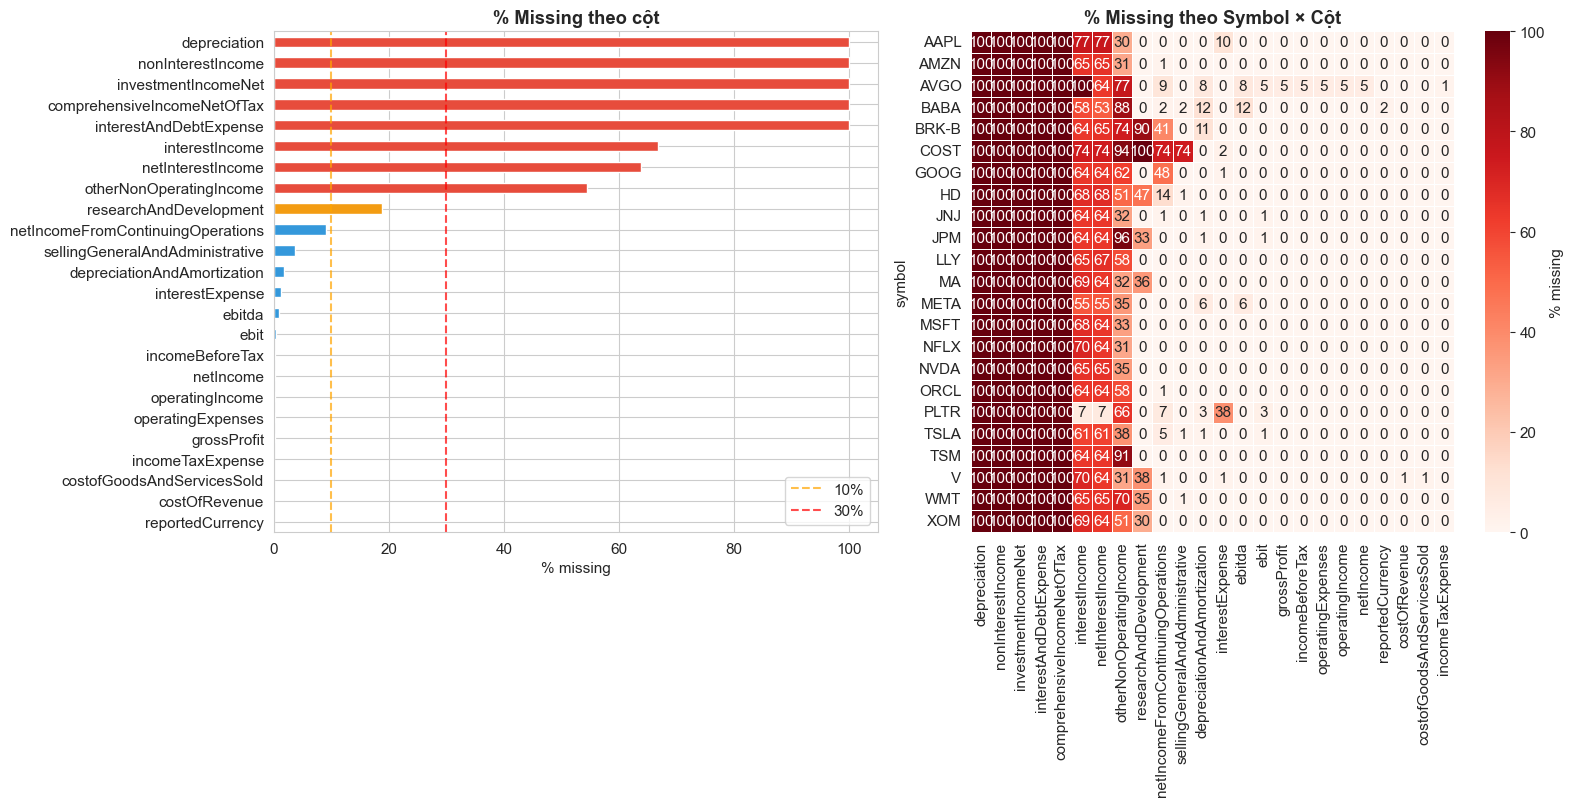

In [7]:
# ── Tổng quan missing ────────────────────────────────────────
missing_pct = (df_raw.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(missing_pct) * 0.3 + 1)))

# Bar chart % missing
colors = ["#e74c3c" if v > 30 else "#f39c12" if v > 10 else "#3498db"
          for v in missing_pct.values]
missing_pct.sort_values().plot(kind="barh", ax=axes[0], color=colors[::-1])
axes[0].axvline(10, color="orange", linestyle="--", alpha=0.7, label="10%")
axes[0].axvline(30, color="red",    linestyle="--", alpha=0.7, label="30%")
axes[0].set_title("% Missing theo cột", fontweight="bold")
axes[0].set_xlabel("% missing")
axes[0].legend()

# Heatmap missing theo symbol
miss_by_sym = df_raw.isnull().groupby(df_raw["symbol"]).mean() * 100
miss_by_sym = miss_by_sym[missing_pct.index]  # chỉ cột có missing
if not miss_by_sym.empty:
    sns.heatmap(miss_by_sym, ax=axes[1], cmap="Reds", annot=True,
                fmt=".0f", linewidths=0.5, cbar_kws={"label": "% missing"})
    axes[1].set_title("% Missing theo Symbol × Cột", fontweight="bold")
    axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


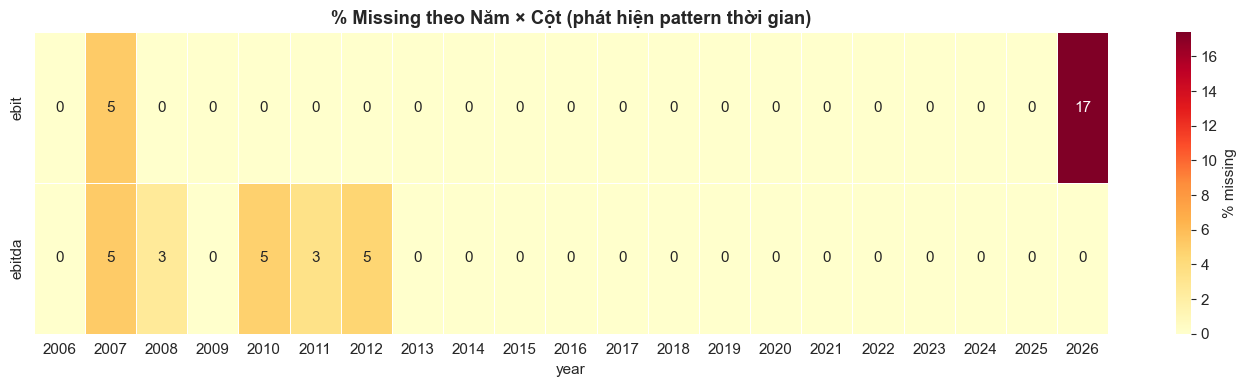

- Nếu missing tập trung ở năm đầu → do công ty mới niêm yết (dùng ffill/bfill theo group).
- Nếu missing rải đều → thiếu dữ liệu thực sự (dùng median imputation theo sector).


In [8]:
# ── Missing theo năm (có pattern thời gian không?) ───────────
df_raw["year"] = df_raw[DATE_COL_RAW].dt.year
miss_by_year = df_raw.groupby("year")[SCALE_COLS_RAW].apply(
    lambda g: g.isnull().mean() * 100
).T

plt.figure(figsize=(14, max(4, len(SCALE_COLS_RAW) * 0.45)))
sns.heatmap(miss_by_year, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.4, cbar_kws={"label": "% missing"})
plt.title("% Missing theo Năm × Cột (phát hiện pattern thời gian)", fontweight="bold")
plt.tight_layout()
plt.show()

print("- Nếu missing tập trung ở năm đầu → do công ty mới niêm yết (dùng ffill/bfill theo group).")
print("- Nếu missing rải đều → thiếu dữ liệu thực sự (dùng median imputation theo sector).")


### **4.3 Phát hiện Outlier**

Dùng **boxplot** để thấy IQR và extreme values, kết hợp **IQR rule** để đếm số điểm outlier theo từng cột.


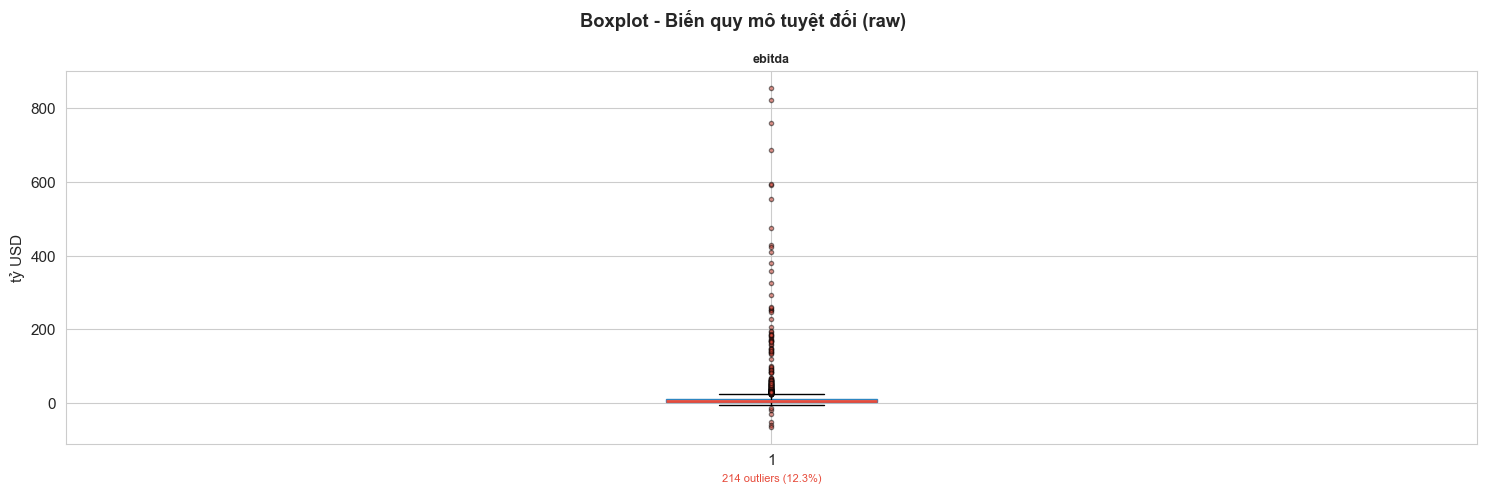

In [9]:
plot_cols = [c for c in ["totalrevenue", "netincome", "grossprofit",
                        "operatingincome", "ebitda"] if c in df_raw.columns]

# 1. Thêm squeeze=False ở đây
fig, axes = plt.subplots(1, len(plot_cols), figsize=(15, 5), squeeze=False)

# 2. Thêm .flatten() vào biến axes ở đây
for ax, col in zip(axes.flatten(), plot_cols):
    data = df_raw[col].dropna() / 1e9
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor="#aed6f1", color="#2e86c1"),
               medianprops=dict(color="#e74c3c", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor="#e74c3c",
                               markersize=3, alpha=0.5))
    
    ax.set_title(col, fontweight="bold", fontsize=9)
    ax.set_ylabel("tỷ USD")
    
    # Annotate số outlier
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax.set_xlabel(f"{n_out} outliers ({n_out/len(data)*100:.1f}%)",
                  color="#e74c3c", fontsize=8)

plt.suptitle("Boxplot - Biến quy mô tuyệt đối (raw)", fontweight="bold")
plt.tight_layout()
plt.show()

In [10]:
# ── Bảng tóm tắt outlier theo IQR rule ──────────────────────
outlier_summary = []
for col in SCALE_COLS_RAW:
    s = df_raw[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_low  = (s < q1 - 1.5*iqr).sum()
    n_high = (s > q3 + 1.5*iqr).sum()
    outlier_summary.append({
        "column"    : col,
        "n_outlier" : n_low + n_high,
        "% outlier" : round((n_low + n_high) / len(s) * 100, 1),
        "n_low"     : n_low,
        "n_high"    : n_high,
        "min"       : round(s.min() / 1e9, 2),
        "max"       : round(s.max() / 1e9, 2),
        "skewness"  : round(s.skew(), 2),
    })

df_out = pd.DataFrame(outlier_summary).sort_values("% outlier", ascending=False)
display(df_out.style
    .background_gradient(subset=["% outlier"], cmap="Reds")
    .format({"% outlier": "{:.1f}%"})
    .set_caption("Outlier summary theo IQR rule (đơn vị tỷ USD)"))


,column,n_outlier,% outlier,n_low,n_high,min,max,skewness
0,ebit,231,13.2%,6,225,-62.070000,657.290000,9.260000
1,ebitda,214,12.3%,6,208,-64.540000,856.230000,9.040000


### **4.4 Phân phối & Kiểm tra Normality**

Histogram + KDE cho thấy hình dạng phân phối (single-peak, bimodal, heavy-tail).
Q-Q plot so sánh trực tiếp raw vs Sign-Log transform — điểm gần đường đỏ hơn = phân phối gần chuẩn hơn.
Hai biểu đồ này là căn cứ để justify lựa chọn **Sign-Log** thay vì `log1p` hay Yeo-Johnson.

- `|skew| > 1` → phân phối lệch mạnh → cần transform  
- Đuôi Q-Q plot sau Sign-Log còn lệch → cân nhắc Yeo-Johnson (đã cài sẵn trong file 02)


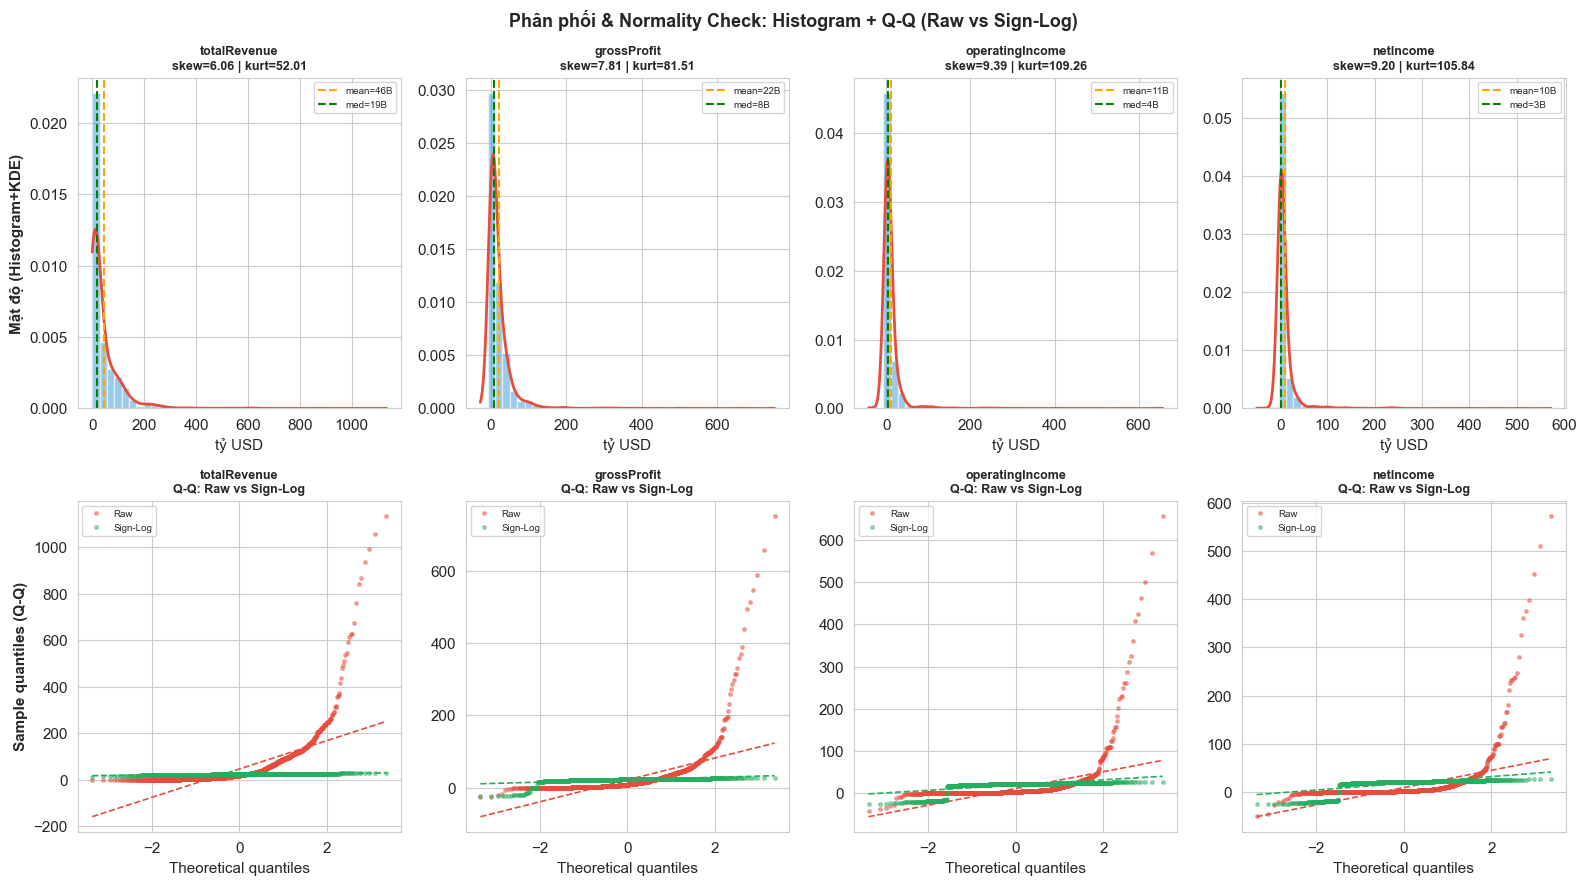

- Cột gần đường thẳng hơn ở hàng dưới → Sign-Log cải thiện normality tốt.
Nếu vẫn còn lệch đuôi nhiều → Yeo-Johnson (đã cài sẵn trong file 02).


In [11]:
# ── Chọn 4 cột đại diện ─────────────────────────────────────────────────────
KEY_COLS = ["totalrevenue", "netincome", "grossprofit", "operatingincome"]
plot_cols = [c for c in df_raw.columns if c.lower() in KEY_COLS][:4]
n = len(plot_cols)

fig, axes = plt.subplots(2, n, figsize=(n * 4, 9))

for j, col in enumerate(plot_cols):
    data = df_raw[col].dropna() / 1e9

    # Hàng trên: Histogram + KDE
    ax_h = axes[0, j]
    ax_h.hist(data, bins=40, density=True, alpha=0.5,
              color="#3498db", edgecolor="white")
    kde = gaussian_kde(data)
    x = np.linspace(data.min(), data.max(), 300)
    ax_h.plot(x, kde(x), color="#e74c3c", linewidth=2)
    ax_h.axvline(data.mean(),   color="orange", linestyle="--",
                 linewidth=1.5, label=f"mean={data.mean():.0f}B")
    ax_h.axvline(data.median(), color="green",  linestyle="--",
                 linewidth=1.5, label=f"med={data.median():.0f}B")
    ax_h.set_title(f"{col}\nskew={data.skew():.2f} | kurt={data.kurt():.2f}",
                   fontweight="bold", fontsize=9)
    ax_h.set_xlabel("tỷ USD")
    ax_h.legend(fontsize=7)

    # Hàng dưới: Q-Q plot Raw vs Sign-Log (chồng trong 1 axes)
    ax_q = axes[1, j]
    data_raw = df_raw[col].dropna()
    data_sl  = np.sign(data_raw) * np.log1p(data_raw.abs())

    # Raw (đỏ)
    (osm_r, osr_r), (slope_r, intercept_r, _) = scipy_stats.probplot(data_raw / 1e9)
    ax_q.plot(osm_r, osr_r, "o", markersize=2.5, alpha=0.45,
              color="#e74c3c", label="Raw")
    ax_q.plot(osm_r, slope_r * np.array(osm_r) + intercept_r,
              color="#e74c3c", linewidth=1.2, linestyle="--")

    # Sign-Log (xanh)
    (osm_s, osr_s), (slope_s, intercept_s, _) = scipy_stats.probplot(data_sl)
    ax_q.plot(osm_s, osr_s, "o", markersize=2.5, alpha=0.45,
              color="#27ae60", label="Sign-Log")
    ax_q.plot(osm_s, slope_s * np.array(osm_s) + intercept_s,
              color="#27ae60", linewidth=1.2, linestyle="--")

    ax_q.set_title(f"{col}\nQ-Q: Raw vs Sign-Log", fontsize=9, fontweight="bold")
    ax_q.set_xlabel("Theoretical quantiles")
    ax_q.legend(fontsize=7)

axes[0, 0].set_ylabel("Mật độ (Histogram+KDE)", fontweight="bold")
axes[1, 0].set_ylabel("Sample quantiles (Q-Q)", fontweight="bold")

plt.suptitle("Phân phối & Normality Check: Histogram + Q-Q (Raw vs Sign-Log)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

print("- Cột gần đường thẳng hơn ở hàng dưới → Sign-Log cải thiện normality tốt.")
print("Nếu vẫn còn lệch đuôi nhiều → Yeo-Johnson (đã cài sẵn trong file 02).")


### **4.5 Phân tích tương quan & Justify ngưỡng loại feature**

> **Lưu ý:** Phân tích tương quan Pearson dưới đây được thực hiện **trên dữ liệu thô (raw)**, trước khi pipeline tiền xử lý chạy. Đây là bước khảo sát để *justify* ngưỡng loại feature trong preprocessing — không phải trên processed data. Kết quả tương quan sau xử lý được trình bày ở mục **5.3**.


In [12]:
# 1. Tự động lấy TẤT CẢ các cột có kiểu dữ liệu là số (int, float)
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns

print(f"Tổng số cột dạng số được đưa vào tính toán: {len(numeric_cols)} cột\n")

# 2. Tính ma trận tương quan cho toàn bộ các cột số này
corr_matrix = df_raw[numeric_cols].corr().abs()

# 3. Lấy tam giác trên của ma trận để không bị trùng lặp (A-B và B-A)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Biến đổi thành dạng bảng và lọc các cặp có |r| > 0.85
high_corr_pairs = upper_tri.stack().reset_index()
high_corr_pairs.columns = ['Biến 1', 'Biến 2', 'Hệ số tương quan (|r|)']
high_corr_pairs = high_corr_pairs[high_corr_pairs['Hệ số tương quan (|r|)'] > 0.85]

# 5. Sắp xếp từ cao xuống thấp và in ra kết quả
high_corr_pairs = high_corr_pairs.sort_values(by='Hệ số tương quan (|r|)', ascending=False)

if high_corr_pairs.empty:
    print("Không có cặp biến nào có tương quan > 0.85.")
else:
    print("Danh sách CÁC CẶP BIẾN CÓ TƯƠNG QUAN CAO (>0.85):")
    display(high_corr_pairs.reset_index(drop=True))

Tổng số cột dạng số được đưa vào tính toán: 25 cột

Danh sách CÁC CẶP BIẾN CÓ TƯƠNG QUAN CAO (>0.85):


,Biến 1,Biến 2,Hệ số tương quan (|r|)
0,costOfRevenue,costofGoodsAndServicesSold,1.0000
1,incomeBeforeTax,netIncome,0.9984
2,incomeBeforeTax,ebit,0.9943
3,ebit,netIncome,0.9930
4,operatingIncome,incomeBeforeTax,0.9885
5,operatingIncome,ebit,0.9877
6,operatingIncome,netIncome,0.9875
7,ebitda,netIncome,0.9673
8,incomeBeforeTax,ebitda,0.9663
9,ebit,ebitda,0.9646


Tổng cột số: 25 → vẽ top 25 cột theo variance


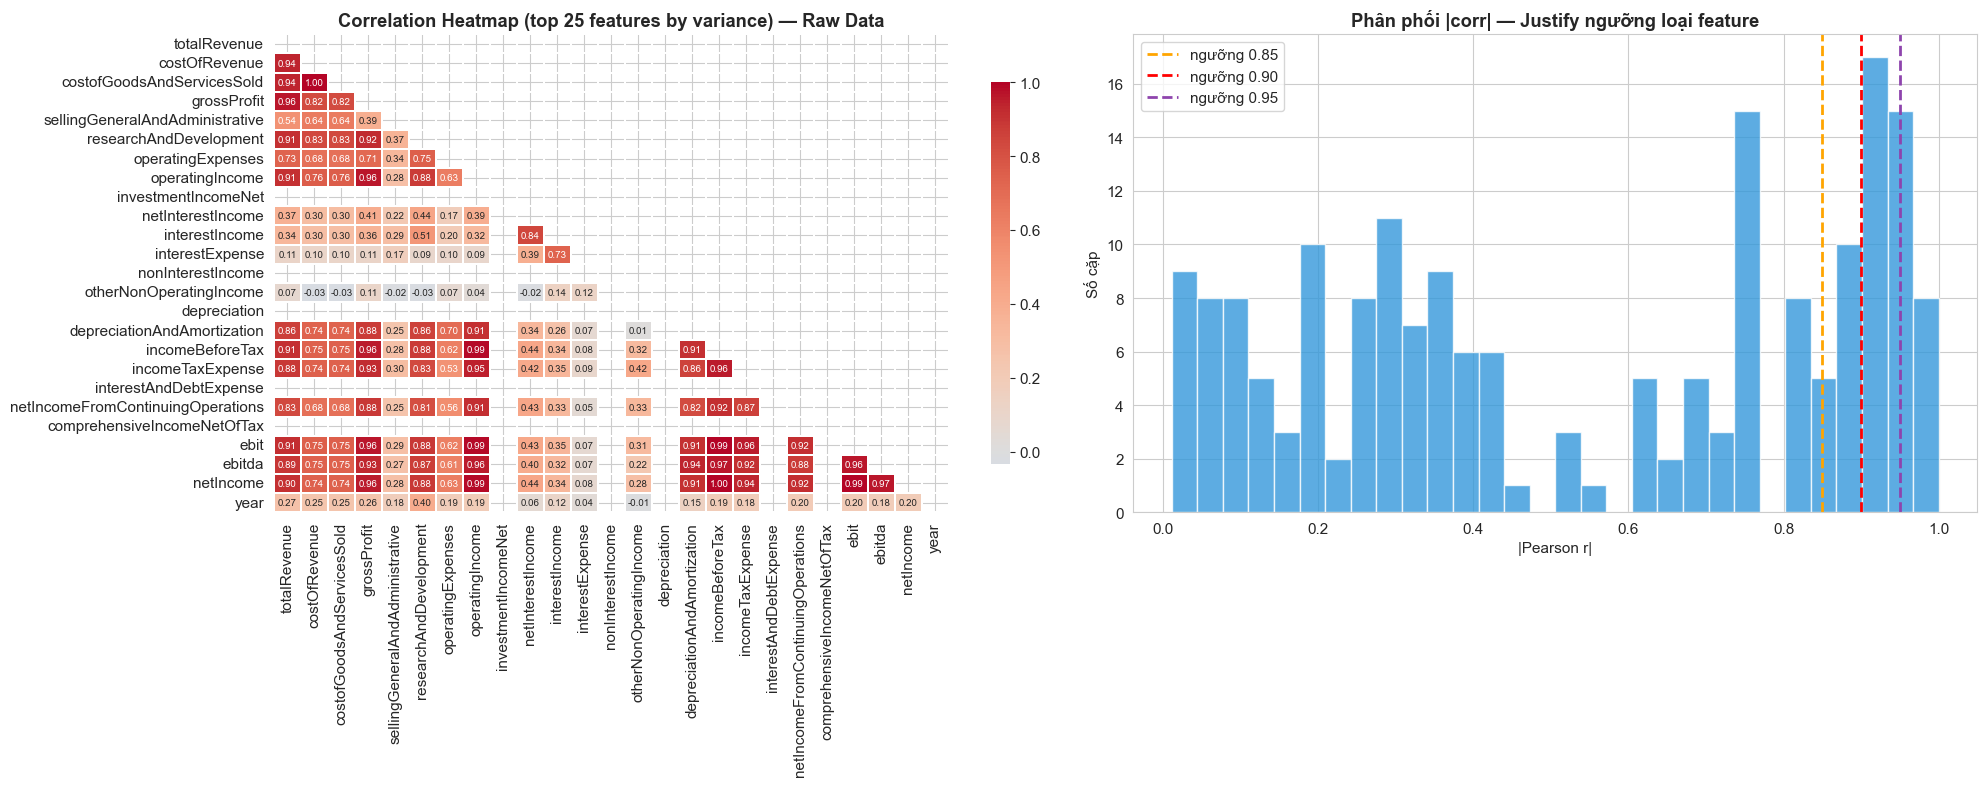

,ngưỡng,số cặp > ngưỡng,feature bị drop (ước tính),feature giữ lại
0,0.800000,63,13,12
1,0.850000,54,12,13
2,0.900000,40,12,13
3,0.950000,18,8,17
4,0.980000,7,4,21


In [13]:
# Tự động lấy TẤT CẢ các cột số
corr_cols_all = df_raw.select_dtypes(include=[np.number]).columns

# ── Giới hạn top 25 cột theo variance để heatmap dễ đọc ─────────────────────
# (Nếu raw có >25 cột số, vẽ toàn bộ sẽ overplot — tương tự cách phần 5.3 xử lý)
top25 = df_raw[corr_cols_all].var().nlargest(25).index.tolist()
corr_cols = [c for c in corr_cols_all if c in top25]
corr_raw  = df_raw[corr_cols].corr()

print(f"Tổng cột số: {len(corr_cols_all)} → vẽ top {len(corr_cols)} cột theo variance")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── Heatmap (top 25, tam giác dưới) ──────────────────────────────────────────
mask = np.triu(np.ones_like(corr_raw, dtype=bool))

sns.heatmap(corr_raw, mask=mask, ax=axes[0],
            annot=True,
            fmt=".2f",
            annot_kws={"size": 7},
            cmap="coolwarm",
            center=0, linewidths=0.3,
            cbar_kws={"shrink": 0.8})
axes[0].set_title(f"Correlation Heatmap (top {len(corr_cols)} features by variance) — Raw Data", fontweight="bold")

# ── Histogram |corr| + bảng ngưỡng ───────────────────────────────────────────
corr_all_mat = df_raw[corr_cols_all].corr().abs()
upper_vals = corr_all_mat.where(
    np.triu(np.ones(corr_all_mat.shape, dtype=bool), k=1)
).stack()

axes[1].hist(upper_vals, bins=30, color="#3498db", edgecolor="white", alpha=0.8)
for thresh, color, label in [(0.85, "orange", "0.85"),
                               (0.90, "red",    "0.90"),
                               (0.95, "#8e44ad","0.95")]:
    axes[1].axvline(thresh, color=color, linestyle="--",
                    linewidth=2, label=f"ngưỡng {label}")
axes[1].set_title("Phân phối |corr| — Justify ngưỡng loại feature", fontweight="bold")
axes[1].set_xlabel("|Pearson r|")
axes[1].set_ylabel("Số cặp")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Bảng: mỗi ngưỡng drop bao nhiêu feature? ─────────────────────────────────
thresholds = [0.80, 0.85, 0.90, 0.95, 0.98]
summary = []
for t in thresholds:
    drop_feats = set()
    for (f1, f2), v in upper_vals.items():
        if v > t:
            drop_feats.add(f2)
    summary.append({
        "ngưỡng"                    : t,
        "số cặp > ngưỡng"           : int((upper_vals > t).sum()),
        "feature bị drop (ước tính)": len(drop_feats),
        "feature giữ lại"           : len(corr_cols_all) - len(drop_feats),
    })
df_thresh = pd.DataFrame(summary)
display(df_thresh.style
    .map(lambda v: "background-color: #e8daef" if v == 0.95 else "",
              subset=["ngưỡng"])
    .set_caption("So sánh ngưỡng |corr| — tím = ngưỡng file 02 đang dùng (tính trên toàn bộ cột số raw)"))


### **4.6 Panel Data EDA — Phân phối theo từng công ty (Symbol)**

Dữ liệu là **panel data** (23 công ty × nhiều quý). EDA pool-level ở trên chưa cho thấy sự khác biệt giữa các công ty — AAPL và XOM có scale revenue rất khác nhau, gộp lại có thể che khuất pattern.

Hai biểu đồ dưới đây phân tích **theo từng symbol** để:
- Phát hiện công ty nào là outlier so với nhóm (scale quá lớn/nhỏ)
- Thấy variance trong từng công ty (box rộng = không ổn định)
- Làm căn cứ chọn **group-wise normalization** thay vì global scaling


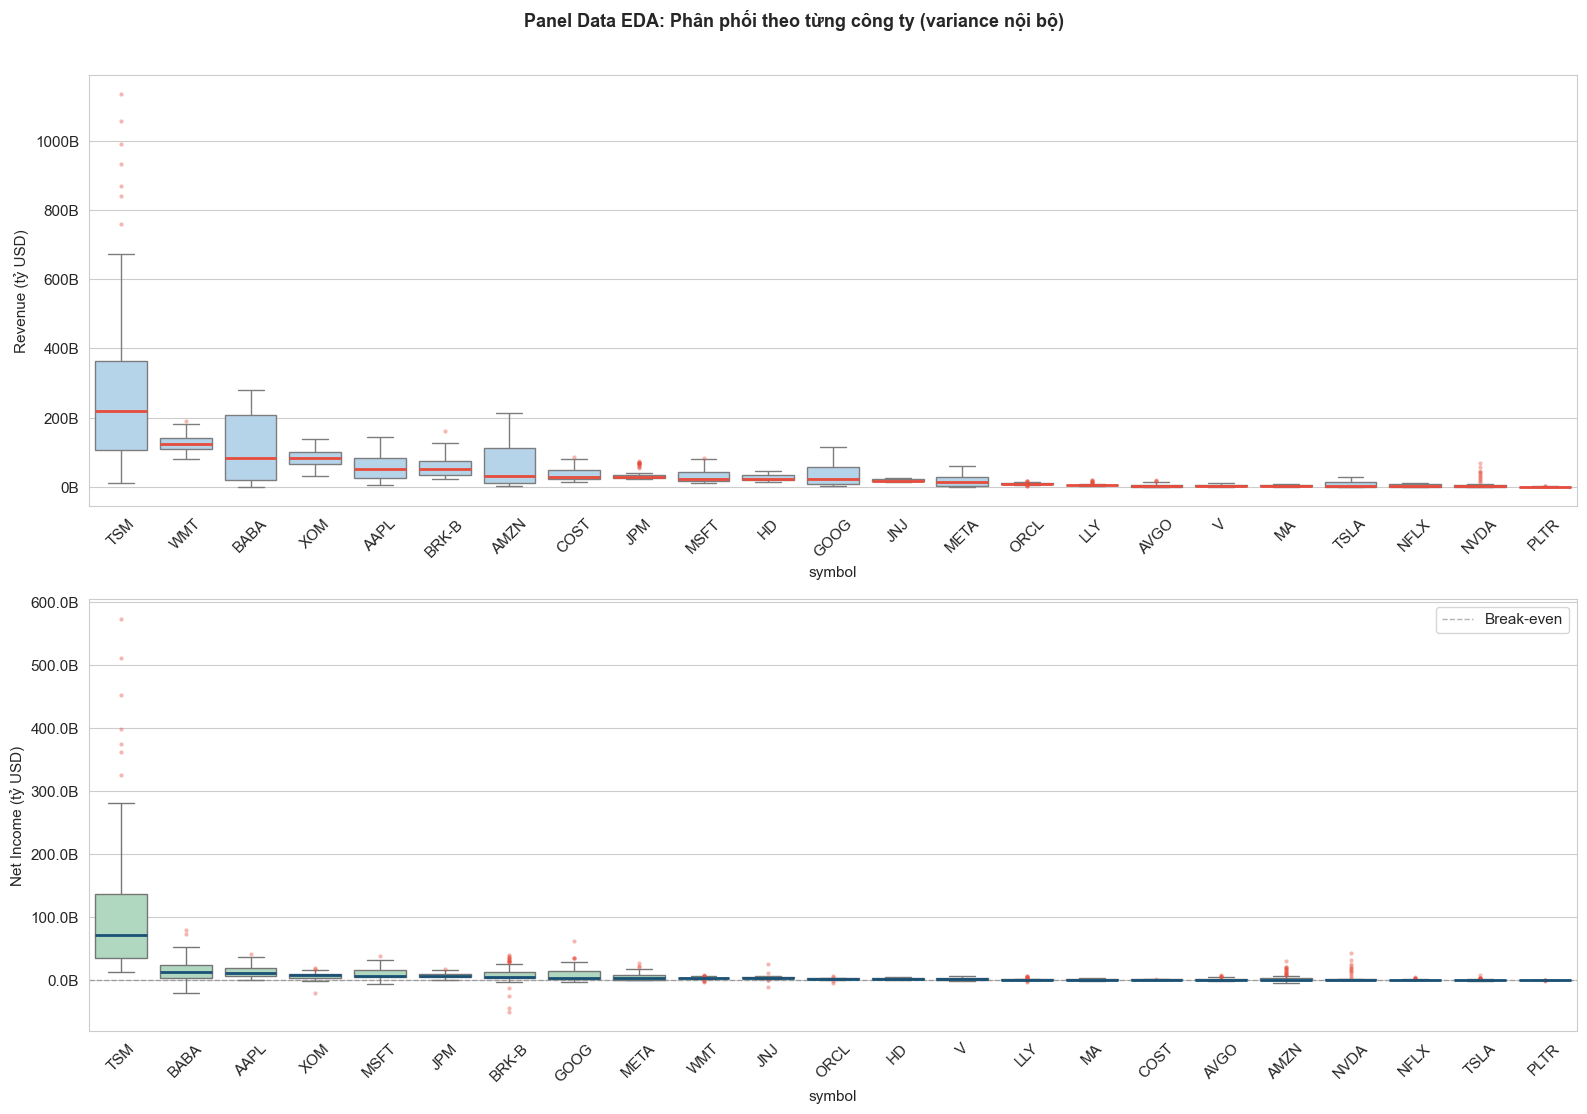

Box rộng → revenue biến động mạnh theo quý (chu kỳ hoặc bất ổn).
Median Net Income < 0 → công ty thua lỗ phần lớn thời gian quan sát.


In [14]:
# ── 4.6 Boxplot Revenue & Net Income theo Symbol ─────────────────────────────
# Cho thấy variance NỘI BỘ từng công ty (box rộng = biến động mạnh theo quý)
# So sánh GIỮA công ty xem 4.8 Ranking — hai góc nhìn bổ sung nhau.

fig, axes = plt.subplots(2, 1, figsize=(16, 11))

rev_col = next((c for c in df_raw.columns if c.lower() == "totalrevenue"), None)
ni_col  = next((c for c in df_raw.columns if c.lower() == "netincome"),    None)

if rev_col:
    # Xác định thứ tự sắp xếp các công ty dựa trên Median giảm dần
    order_rev = (df_raw.groupby("symbol")[rev_col].median()
                       .sort_values(ascending=False).index.tolist())
    
    # Chuyển sang dùng Seaborn để hỗ trợ tham số 'order' hoàn hảo
    sns.boxplot(
        data=df_raw, x="symbol", y=rev_col, ax=axes[0], order=order_rev,
        color="#aed6f1",  # Màu nền của các box
        medianprops=dict(color="#e74c3c", linewidth=2), # Đường median màu đỏ
        flierprops=dict(marker="o", markersize=3, alpha=0.4, markerfacecolor="#e74c3c", markeredgecolor="none") # Điểm outlier
    )
    axes[0].set_title("Revenue theo Symbol — sắp xếp theo median (IQR = variance quý)",
                      fontweight="bold")
    axes[0].set_ylabel("Revenue (tỷ USD)")
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e9:.0f}B"))
    axes[0].tick_params(axis="x", rotation=45)
    plt.sca(axes[0]); plt.title("")

if ni_col:
    order_ni = (df_raw.groupby("symbol")[ni_col].median()
                      .sort_values(ascending=False).index.tolist())
    sns.boxplot(
        data=df_raw, x="symbol", y=ni_col, ax=axes[1], order=order_ni,
        color="#a9dfbf",  # Màu nền của các box
        medianprops=dict(color="#1a5276", linewidth=2), # Đường median màu xanh
        flierprops=dict(marker="o", markersize=3, alpha=0.4, markerfacecolor="#e74c3c", markeredgecolor="none") # Điểm outlier
    )
    
    axes[1].set_title("Net Income theo Symbol — sắp xếp theo median",
                      fontweight="bold")
    axes[1].set_ylabel("Net Income (tỷ USD)")
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B"))
    axes[1].axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="Break-even")
    axes[1].legend()
    axes[1].tick_params(axis="x", rotation=45)
    plt.sca(axes[1]); plt.title("")

plt.suptitle("Panel Data EDA: Phân phối theo từng công ty (variance nội bộ)",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Box rộng → revenue biến động mạnh theo quý (chu kỳ hoặc bất ổn).")
print("Median Net Income < 0 → công ty thua lỗ phần lớn thời gian quan sát.")


### **4.7 Kiểm tra tính liên tục chuỗi thời gian (Time-Series Gap Check)**

Với dữ liệu hàng quý, cần kiểm tra xem có **quý bị thiếu** giữa chừng không — gap trong chuỗi thời gian làm sai `shift(4)` (YoY) và rolling features.

- **Gap = 0** → chuỗi liên tục 
- **Gap > 90 ngày** → có ít nhất 1 quý bị nhảy → cần investigate


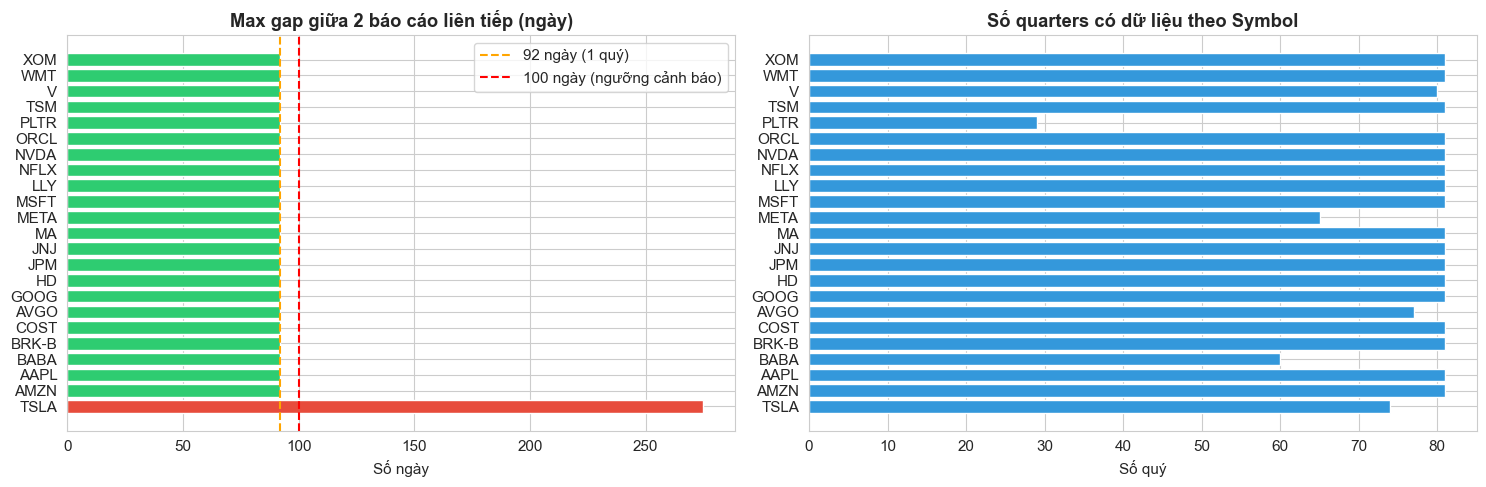


Bảng gap summary:


,symbol,n_quarters,min_gap_days,max_gap_days,median_gap,n_gaps_over_100,gap_ok
18,TSLA,74,90 ngày,275 ngày,92 ngày,2,⚠️
1,AMZN,81,90 ngày,92 ngày,92 ngày,0,✅
0,AAPL,81,90 ngày,92 ngày,92 ngày,0,✅
3,BABA,60,90 ngày,92 ngày,92 ngày,0,✅
4,BRK-B,81,90 ngày,92 ngày,92 ngày,0,✅
5,COST,81,90 ngày,92 ngày,92 ngày,0,✅
2,AVGO,77,89 ngày,92 ngày,92 ngày,0,✅
6,GOOG,81,90 ngày,92 ngày,92 ngày,0,✅
7,HD,81,89 ngày,92 ngày,92 ngày,0,✅
9,JPM,81,90 ngày,92 ngày,92 ngày,0,✅



- 1 công ty có gap > 100 ngày — kiểm tra lại trước khi dùng shift/rolling.


In [15]:
# ── Kiểm tra gap giữa các quý theo từng symbol ──────────────────────────────
gap_records = []
for sym, grp in df_raw.groupby("symbol"):
    dates = grp[DATE_COL_RAW].sort_values().dropna()
    if len(dates) < 2:
        continue
    diffs = dates.diff().dt.days.dropna()
    gap_records.append({
        "symbol"        : sym,
        "n_quarters"    : len(dates),
        "min_gap_days"  : int(diffs.min()),
        "max_gap_days"  : int(diffs.max()),
        "median_gap"    : round(diffs.median(), 0),
        "n_gaps_over_100": int((diffs > 100).sum()),  # > 100 ngày → nghi ngờ
        "gap_ok"        : "✅" if diffs.max() <= 100 else "⚠️",
    })

df_gaps = pd.DataFrame(gap_records).sort_values("max_gap_days", ascending=False)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_gap = ["#e74c3c" if g > 100 else "#2ecc71"
              for g in df_gaps["max_gap_days"]]
axes[0].barh(df_gaps["symbol"], df_gaps["max_gap_days"],
             color=colors_gap, edgecolor="white")
axes[0].axvline(92, color="orange", linestyle="--", linewidth=1.5,
                label="92 ngày (1 quý)")
axes[0].axvline(100, color="red", linestyle="--", linewidth=1.5,
                label="100 ngày (ngưỡng cảnh báo)")
axes[0].set_title("Max gap giữa 2 báo cáo liên tiếp (ngày)",
                  fontweight="bold")
axes[0].set_xlabel("Số ngày")
axes[0].legend()

axes[1].barh(df_gaps["symbol"], df_gaps["n_quarters"],
             color="#3498db", edgecolor="white")
axes[1].set_title("Số quarters có dữ liệu theo Symbol", fontweight="bold")
axes[1].set_xlabel("Số quý")

plt.tight_layout()
plt.show()

# Bảng chi tiết
print("\nBảng gap summary:")
display(df_gaps.style
    .map(lambda v: "background-color: #ffcccc" if v == "⚠️" else "",
              subset=["gap_ok"])
    .format({"median_gap": "{:.0f} ngày", "max_gap_days": "{} ngày",
             "min_gap_days": "{} ngày"})
    .set_caption("Time-Series Gap Check — ⚠️ = có quý bị thiếu"))

n_warn = (df_gaps["gap_ok"] == "⚠️").sum()
if n_warn == 0:
    print("\n- Tất cả chuỗi thời gian liên tục — không có gap đáng lo ngại.")
else:
    print(f"\n- {n_warn} công ty có gap > 100 ngày — kiểm tra lại trước khi dùng shift/rolling.")


### **4.8 Ranking Doanh Thu Doanh Nghiệp**

Ba góc nhìn ranking để thấy ai dẫn đầu, ai bứt phá, và ngành nào chiếm ưu thế:

| Sub-section | Câu hỏi trả lời |
|---|---|
| **4.8a** Top doanh thu từng năm | Năm X, công ty nào có tổng revenue cao nhất? |
| **4.8b** Ranking trong 1 năm cụ thể | Bức tranh tương đối giữa 23 công ty tại 1 thời điểm |
| **4.8c** Top doanh thu theo ngành | Ai đại diện mỗi sector? Revenue phân bổ ra sao? |

**Dữ liệu:** Tổng revenue theo năm = tổng 4 quý (`resample` hoặc `groupby year`).  
**Đơn vị:** tỷ USD (billions).

> **Liên kết với pipeline ML:** Sự chênh lệch revenue scale lớn giữa các sector (ví dụ: Technology vs Energy) và giữa các công ty trong cùng sector là lý do chính để dùng **sector-wise winsorization** trong bước tiền xử lý (file 02). Nếu dùng global scaling, các giá trị cực lớn từ AAPL/MSFT/AMZN sẽ đẩy threshold winsorize quá cao, không phát hiện được outlier ở các công ty nhỏ hơn trong cùng ngành.


In [16]:
# ── Chuẩn bị: tổng revenue theo symbol × năm ────────────────────────────────
rev_col = next((c for c in df_raw.columns if c.lower() == "totalrevenue"), None)
assert rev_col, f"- Không tìm thấy cột totalrevenue. Columns: {df_raw.columns.tolist()[:10]}"

df_raw["year"] = df_raw[DATE_COL_RAW].dt.year

# Tổng revenue cả năm = sum 4 quý
rev_annual = (
    df_raw.groupby(["symbol", "year"])[rev_col]
          .sum()
          .reset_index()
          .rename(columns={rev_col: "annual_revenue"})
)
rev_annual["annual_revenue_B"] = rev_annual["annual_revenue"] / 1e9  # tỷ USD

# Thêm sector
rev_annual["sector"] = rev_annual["symbol"].map(SYMBOL_SECTOR_MAP).fillna("Other")

years_available = sorted(rev_annual["year"].unique())
print(f"- Dữ liệu revenue theo năm: {len(rev_annual)} rows | Năm: {years_available[0]}–{years_available[-1]}")
print(f"   Số công ty: {rev_annual['symbol'].nunique()}")
rev_annual.head(3)


- Dữ liệu revenue theo năm: 459 rows | Năm: 2006–2026
   Số công ty: 23


,symbol,year,annual_revenue,annual_revenue_B,sector
0,AAPL,2006,20214000000.0000,20.2140,Technology
1,AAPL,2007,26499000000.0000,26.4990,Technology
2,AAPL,2008,34751000000.0000,34.7510,Technology


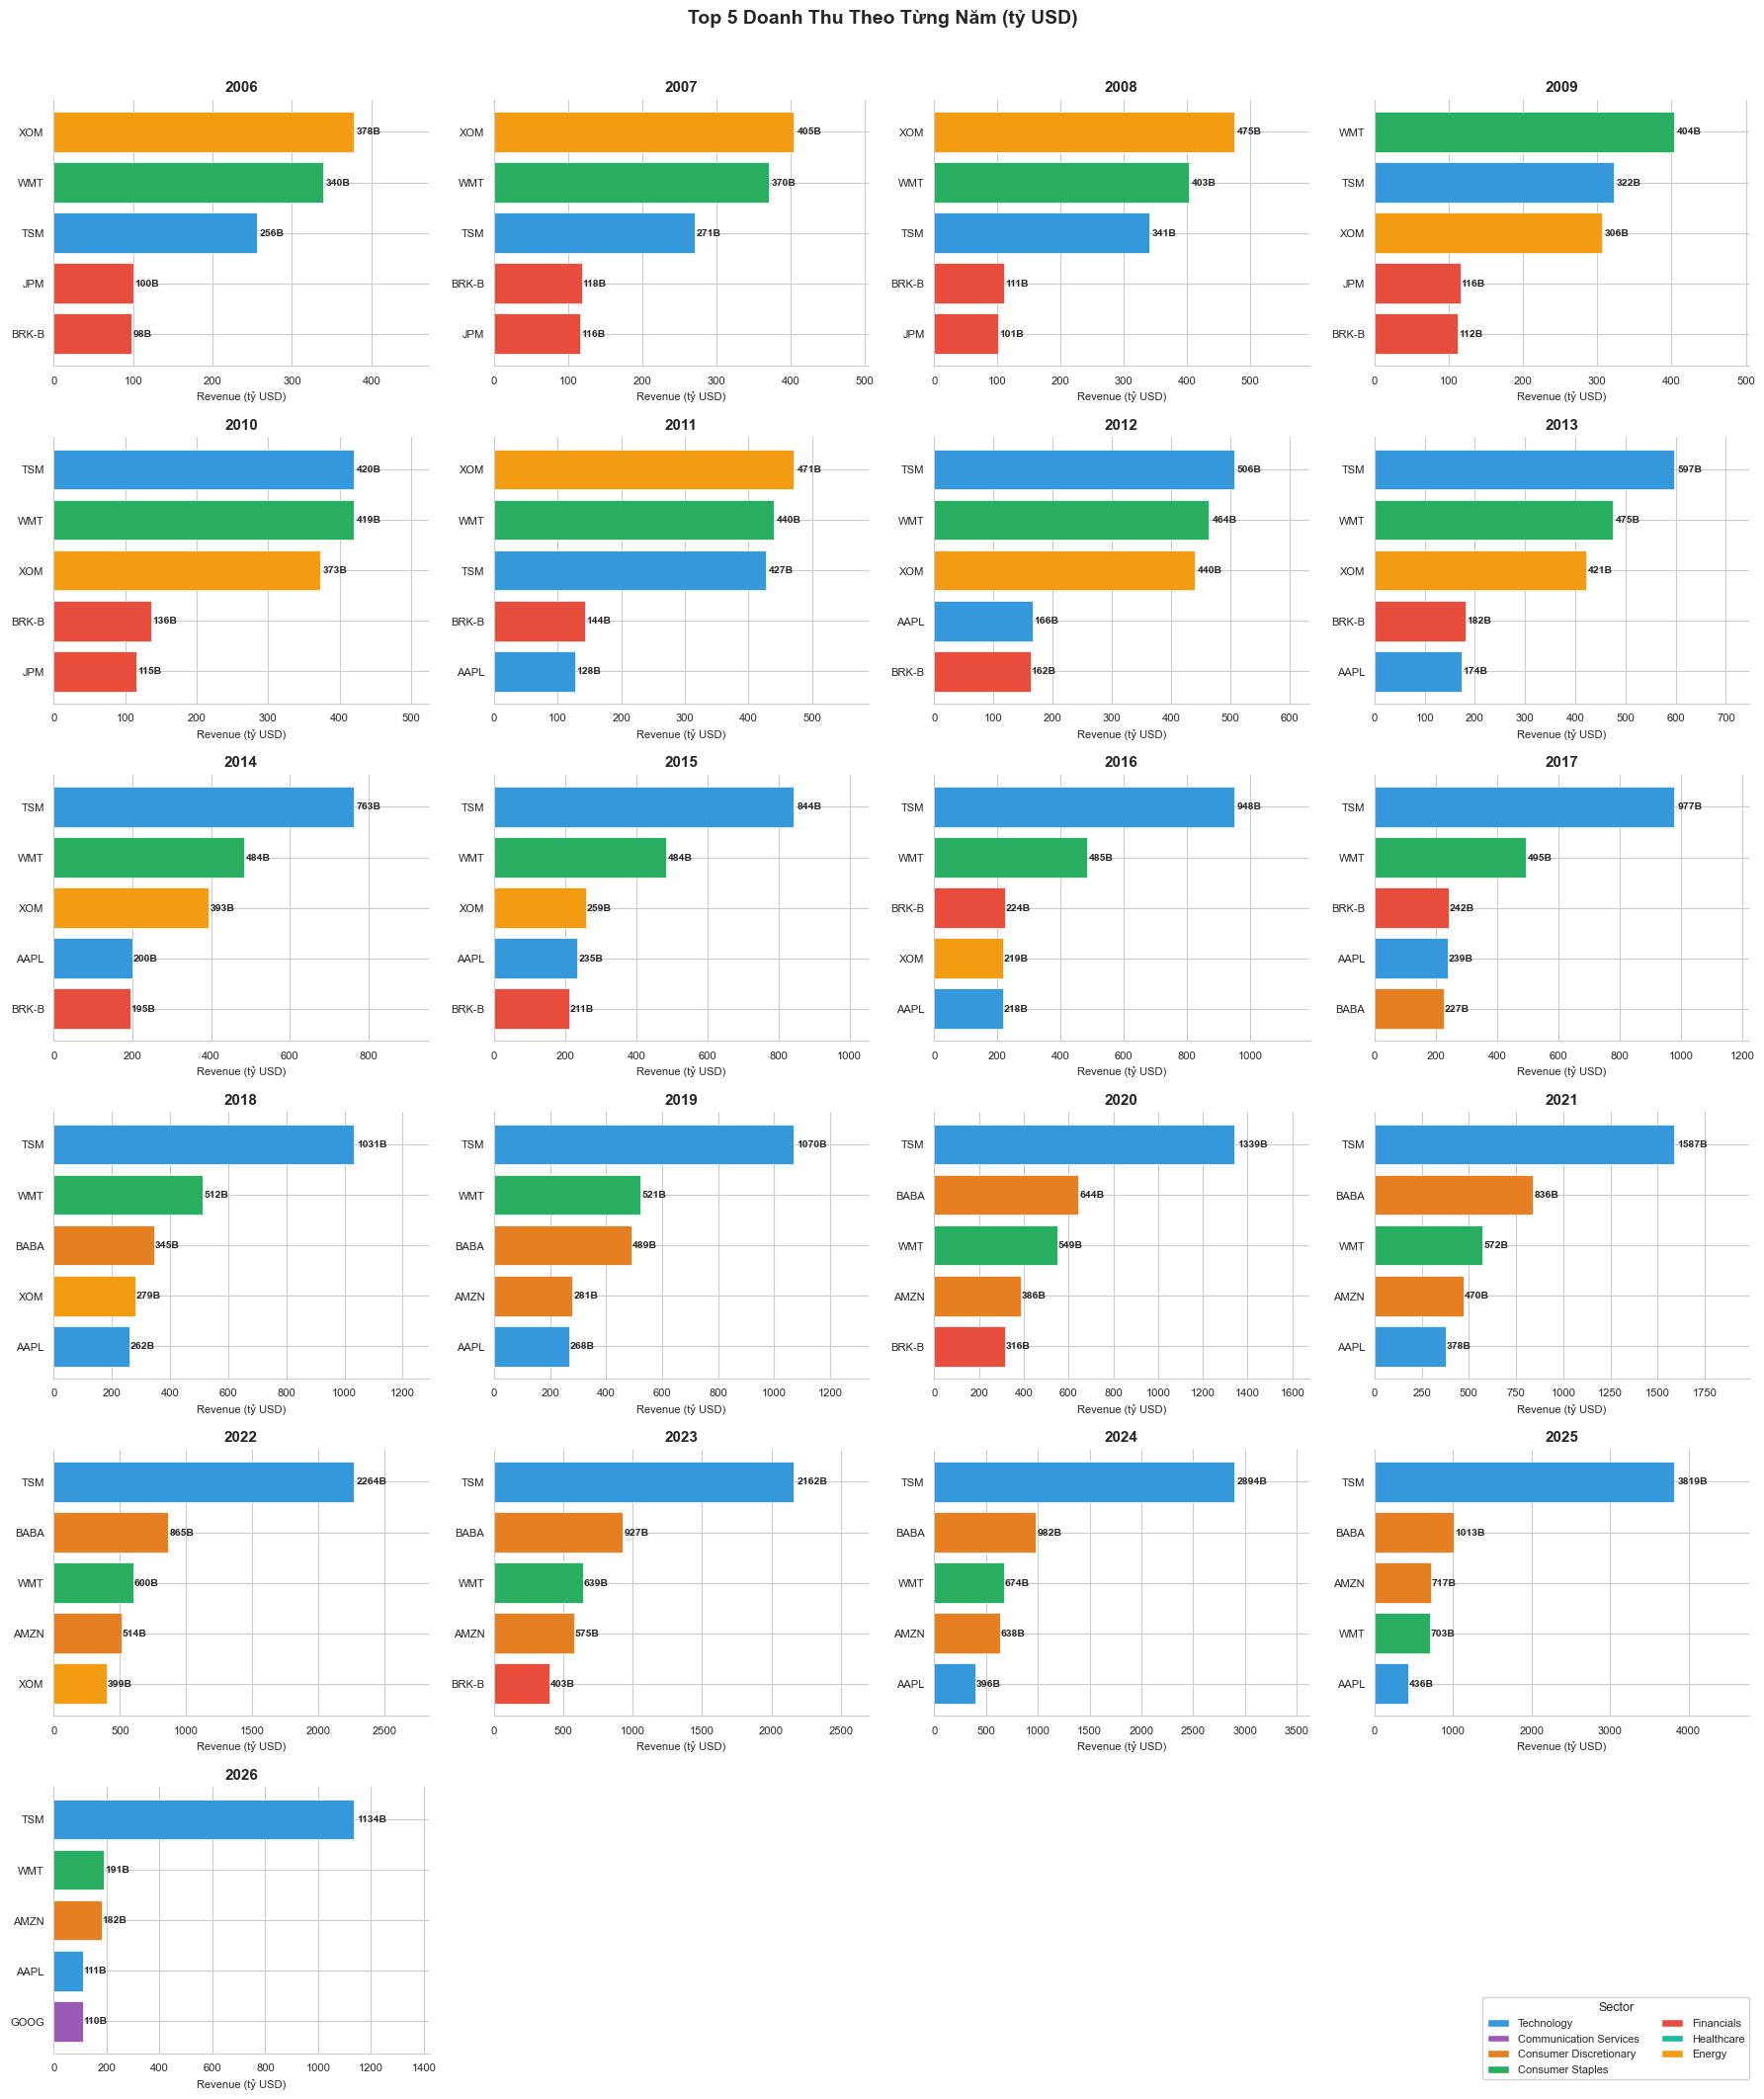


- Công ty đứng #1 doanh thu từng năm:


,year,symbol,sector,Revenue (tỷ USD)
0,2006,XOM,Energy,377.6000
1,2007,XOM,Energy,404.6000
2,2008,XOM,Energy,474.5000
3,2009,WMT,Consumer Staples,403.6000
4,2010,TSM,Technology,419.5000
5,2011,XOM,Energy,471.1000
6,2012,TSM,Technology,506.3000
7,2013,TSM,Technology,597.0000
8,2014,TSM,Technology,762.8000
9,2015,TSM,Technology,843.5000


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.8a — Top N doanh thu TỪNG NĂM (animated-style: small multiples)
# ─────────────────────────────────────────────────────────────────────────────
TOP_N = 5  # số công ty top mỗi năm

# Lấy top N mỗi năm
top_per_year = (
    rev_annual.sort_values(["year", "annual_revenue_B"], ascending=[True, False])
              .groupby("year")
              .head(TOP_N)
)

# Màu theo sector
sector_colors = {
    "Technology"              : "#3498db",
    "Communication Services"  : "#9b59b6",
    "Consumer Discretionary"  : "#e67e22",
    "Consumer Staples"        : "#27ae60",
    "Financials"              : "#e74c3c",
    "Healthcare"              : "#1abc9c",
    "Energy"                  : "#f39c12",
    "Other"                   : "#95a5a6",
}

years = sorted(top_per_year["year"].unique())
ncols = 4
nrows = -(-len(years) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 4.5, nrows * 3.5),
                          sharey=False)
axes = axes.flatten()

for idx, yr in enumerate(years):
    ax = axes[idx]
    df_yr = (top_per_year[top_per_year["year"] == yr]
             .sort_values("annual_revenue_B", ascending=True))  # ascending để barh đúng chiều

    colors = [sector_colors.get(s, "#95a5a6") for s in df_yr["sector"]]
    bars = ax.barh(df_yr["symbol"], df_yr["annual_revenue_B"],
                   color=colors, edgecolor="white", linewidth=0.5)

    # Label giá trị
    for bar, val in zip(bars, df_yr["annual_revenue_B"]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.0f}B", va="center", fontsize=7.5, fontweight="bold")

    ax.set_title(str(yr), fontweight="bold", fontsize=11)
    ax.set_xlabel("Revenue (tỷ USD)", fontsize=8)
    ax.set_xlim(0, df_yr["annual_revenue_B"].max() * 1.25)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# Ẩn axes thừa
for ax in axes[len(years):]:
    ax.set_visible(False)

# Legend sector
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in sector_colors.items()
                   if s in rev_annual["sector"].values]
fig.legend(handles=legend_elements, loc="lower right",
           ncol=2, fontsize=8, title="Sector", title_fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.99, 0.01))

plt.suptitle(f"Top {TOP_N} Doanh Thu Theo Từng Năm (tỷ USD)",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("revenue_ranking_per_year.png", dpi=150, bbox_inches="tight")
plt.show()

# Bảng số 1
print(f"\n- Công ty đứng #1 doanh thu từng năm:")
rank1 = (rev_annual.sort_values(["year","annual_revenue_B"], ascending=[True,False])
                   .groupby("year")
                   .first()
                   .reset_index()[["year","symbol","sector","annual_revenue_B"]])
rank1["annual_revenue_B"] = rank1["annual_revenue_B"].round(1)
display(rank1.rename(columns={"annual_revenue_B": "Revenue (tỷ USD)"}))


Năm được chọn: 2026 (23 công ty)


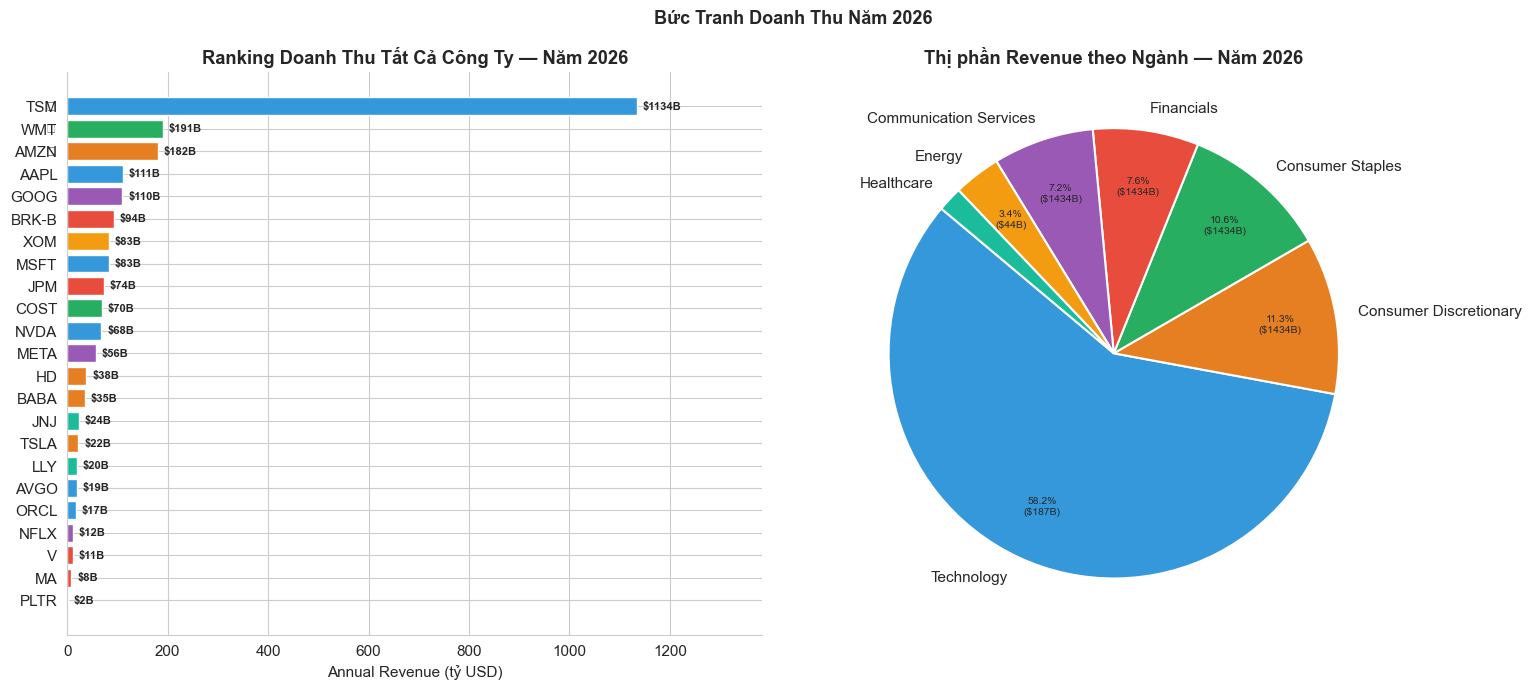


- Top 10 doanh thu năm 2026:


,Hạng,symbol,sector,Revenue (tỷ USD)
0,1,TSM,Technology,$1134.1B
1,2,WMT,Consumer Staples,$190.7B
2,3,AMZN,Consumer Discretionary,$181.5B
3,4,AAPL,Technology,$111.2B
4,5,GOOG,Communication Services,$109.9B
5,6,BRK-B,Financials,$93.7B
6,7,XOM,Energy,$83.2B
7,8,MSFT,Technology,$82.9B
8,9,JPM,Financials,$73.7B
9,10,COST,Consumer Staples,$69.6B


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.8b — Ranking trong 1 NĂM CỤ THỂ (chọn năm gần nhất có đủ dữ liệu)
# ─────────────────────────────────────────────────────────────────────────────
# Chọn năm có nhiều công ty nhất (thường là năm gần nhất đủ 4 quý)
year_counts = rev_annual.groupby("year")["symbol"].nunique()
SELECT_YEAR = int(year_counts[year_counts == year_counts.max()].index[-1])
print(f"Năm được chọn: {SELECT_YEAR} ({year_counts[SELECT_YEAR]} công ty)")

df_year = (rev_annual[rev_annual["year"] == SELECT_YEAR]
           .sort_values("annual_revenue_B", ascending=False)
           .reset_index(drop=True))
df_year["rank"] = df_year.index + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Horizontal bar chart toàn bộ ────────────────────────────────────────────
colors_full = [sector_colors.get(s, "#95a5a6") for s in df_year["sector"]]
bars = axes[0].barh(df_year["symbol"][::-1],
                    df_year["annual_revenue_B"][::-1],
                    color=colors_full[::-1], edgecolor="white")

for bar, val in zip(bars, df_year["annual_revenue_B"][::-1]):
    axes[0].text(bar.get_width() + df_year["annual_revenue_B"].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f"${val:.0f}B", va="center", fontsize=8, fontweight="bold")

axes[0].set_title(f"Ranking Doanh Thu Tất Cả Công Ty — Năm {SELECT_YEAR}",
                  fontweight="bold")
axes[0].set_xlabel("Annual Revenue (tỷ USD)")
axes[0].set_xlim(0, df_year["annual_revenue_B"].max() * 1.22)
axes[0].spines[["top", "right"]].set_visible(False)

# Highlight top 3
for i, (sym, rev, sec) in enumerate(
        zip(df_year["symbol"], df_year["annual_revenue_B"], df_year["sector"])):
    rank_pos = len(df_year) - 1 - df_year[df_year["symbol"] == sym].index[0]
    if i < 3:
        medal = ["🥇", "🥈", "🥉"][i]
        axes[0].text(-df_year["annual_revenue_B"].max() * 0.02, rank_pos,
                     medal, va="center", ha="right", fontsize=10)

# ── Pie chart thị phần revenue theo sector ──────────────────────────────────
sec_rev = (df_year.groupby("sector")["annual_revenue_B"].sum()
                  .sort_values(ascending=False))
pie_colors = [sector_colors.get(s, "#95a5a6") for s in sec_rev.index]
wedges, texts, autotexts = axes[1].pie(
    sec_rev.values,
    labels=sec_rev.index,
    autopct=lambda p: f"{p:.1f}%\n(${sec_rev.values[list(sec_rev.values).index(sec_rev.values[int(round((p/100)*len(sec_rev))-1)])]/1:.0f}B)" if p > 3 else "",
    colors=pie_colors,
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(7.5)
axes[1].set_title(f"Thị phần Revenue theo Ngành — Năm {SELECT_YEAR}",
                  fontweight="bold")

plt.suptitle(f"Bức Tranh Doanh Thu Năm {SELECT_YEAR}", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"revenue_ranking_{SELECT_YEAR}.png", dpi=150, bbox_inches="tight")
plt.show()

# Bảng top 10
print(f"\n- Top 10 doanh thu năm {SELECT_YEAR}:")
display(df_year[["rank","symbol","sector","annual_revenue_B"]]
        .head(10)
        .rename(columns={"annual_revenue_B": "Revenue (tỷ USD)", "rank": "Hạng"})
        .style.format({"Revenue (tỷ USD)": "${:.1f}B"})
        .background_gradient(subset=["Revenue (tỷ USD)"], cmap="Blues"))


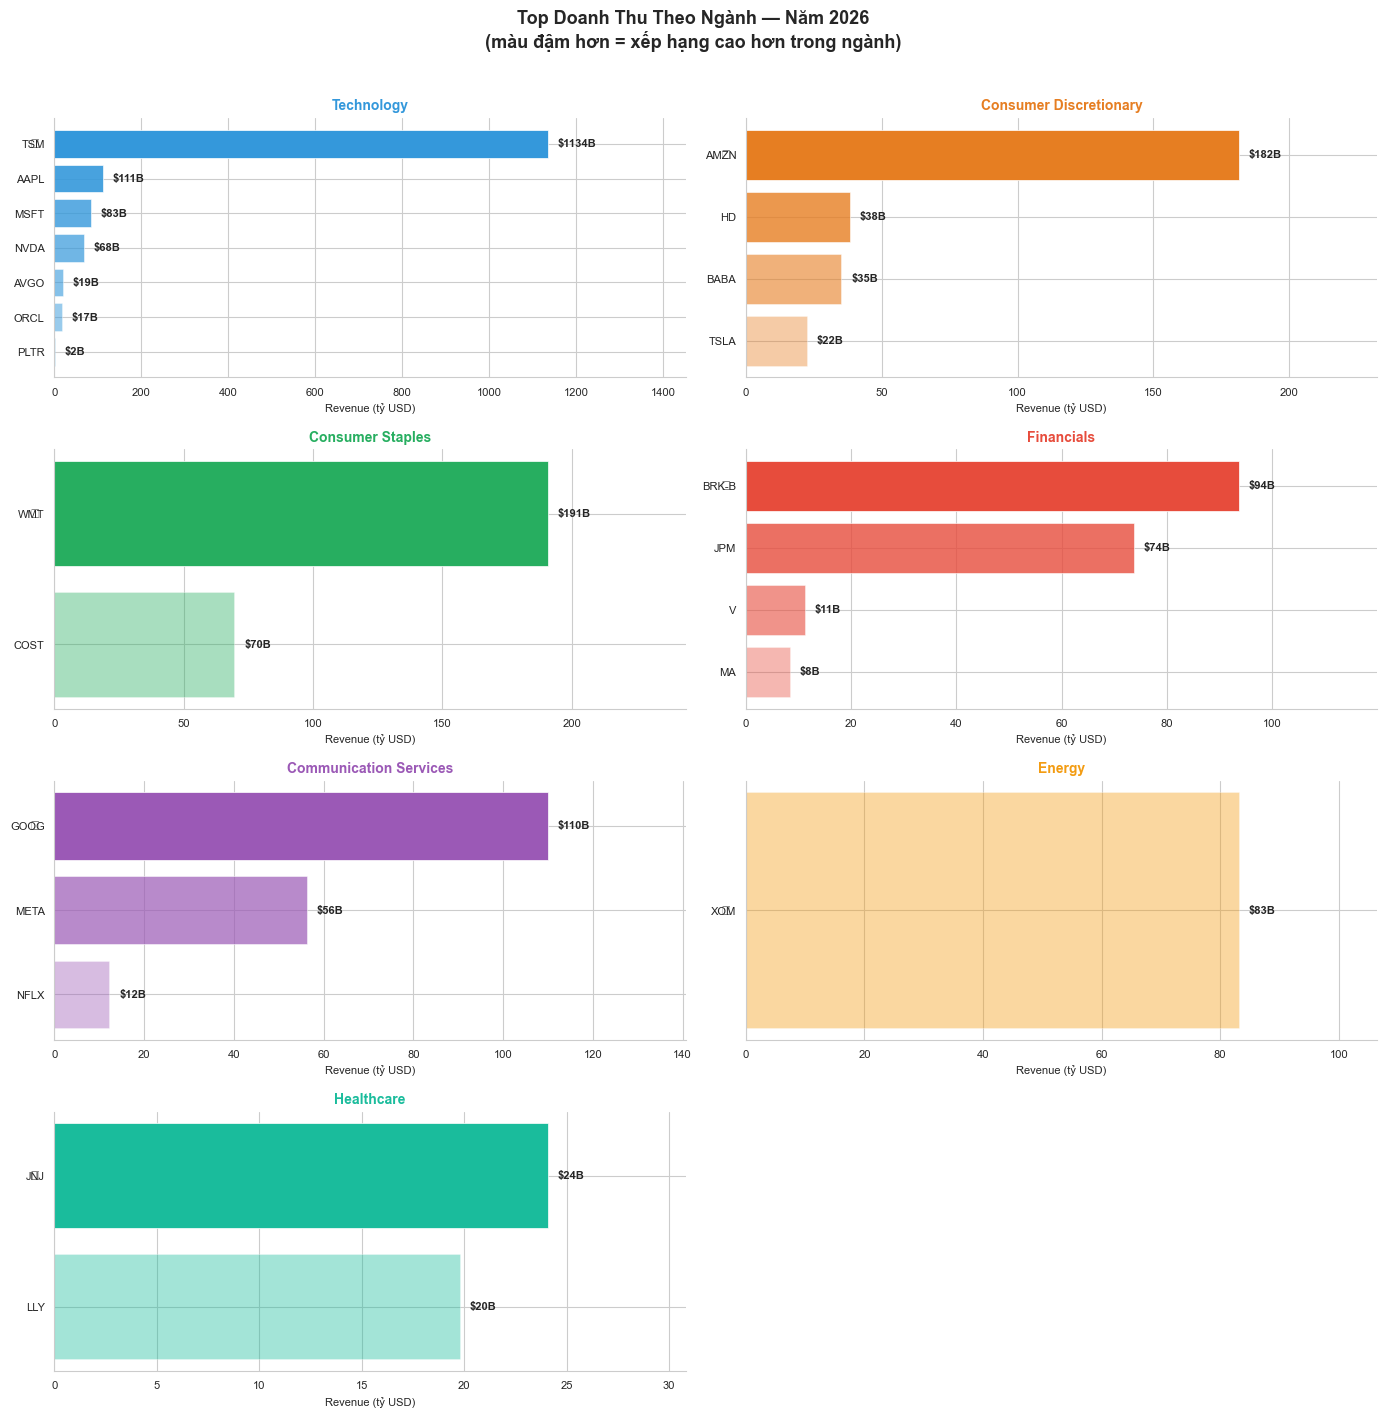


- Công ty dẫn đầu mỗi ngành qua các năm:


year,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
sector,,,,,,,,,,,,,,,,,,,,,
Communication Services,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG
Consumer Discretionary,HD,HD,HD,HD,HD,HD,HD,HD,AMZN,AMZN,BABA,BABA,BABA,BABA,BABA,BABA,BABA,BABA,BABA,BABA,AMZN
Consumer Staples,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT,WMT
Energy,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM,XOM
Financials,JPM,BRK-B,BRK-B,JPM,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B,BRK-B
Healthcare,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ,JNJ
Technology,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM,TSM


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.8c — Top doanh thu THEO NGÀNH (mỗi sector: ai đứng đầu?)
# ─────────────────────────────────────────────────────────────────────────────
# Dùng năm SELECT_YEAR (đã tính ở cell trên)
# Nếu chạy cell này riêng, uncomment dòng dưới:
# SELECT_YEAR = int(rev_annual.groupby("year")["symbol"].nunique().idxmax())

sectors_ordered = (rev_annual[rev_annual["year"] == SELECT_YEAR]
                   .groupby("sector")["annual_revenue_B"].sum()
                   .sort_values(ascending=False).index.tolist())

ncols_s = 2
nrows_s = -(-len(sectors_ordered) // ncols_s)
fig, axes = plt.subplots(nrows_s, ncols_s,
                          figsize=(ncols_s * 7, nrows_s * 3.5))
axes = axes.flatten()

for idx, sector in enumerate(sectors_ordered):
    ax = axes[idx]
    df_sec = (rev_annual[(rev_annual["sector"] == sector) &
                          (rev_annual["year"] == SELECT_YEAR)]
              .sort_values("annual_revenue_B", ascending=True))

    base_color = sector_colors.get(sector, "#95a5a6")
    # Gradient: top bar đậm hơn
    n = len(df_sec)
    alpha_list = [0.4 + 0.6 * (i / max(n - 1, 1)) for i in range(n)]

    for i, (_, row) in enumerate(df_sec.iterrows()):
        bar = ax.barh(row["symbol"], row["annual_revenue_B"],
                      color=base_color, alpha=alpha_list[i],
                      edgecolor="white", linewidth=0.5)
        ax.text(row["annual_revenue_B"] + df_sec["annual_revenue_B"].max() * 0.02,
                i, f"${row['annual_revenue_B']:.0f}B",
                va="center", fontsize=8, fontweight="bold")

    ax.set_title(f"{sector}", fontweight="bold",
                 color=base_color, fontsize=10)
    ax.set_xlabel("Revenue (tỷ USD)", fontsize=8)
    ax.set_xlim(0, df_sec["annual_revenue_B"].max() * 1.28)
    ax.tick_params(labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

    # Medal top 1 trong sector
    top1 = df_sec.iloc[-1]
    ax.text(-df_sec["annual_revenue_B"].max() * 0.03, n - 1,
            "🏆", va="center", ha="right", fontsize=10)

for ax in axes[len(sectors_ordered):]:
    ax.set_visible(False)

plt.suptitle(f"Top Doanh Thu Theo Ngành — Năm {SELECT_YEAR}\n"
             f"(màu đậm hơn = xếp hạng cao hơn trong ngành)",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("revenue_ranking_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary table: top 1 mỗi ngành qua các năm ──────────────────────────────
print("\n- Công ty dẫn đầu mỗi ngành qua các năm:")
leader_by_sector_year = (
    rev_annual.sort_values(["sector", "year", "annual_revenue_B"],
                           ascending=[True, True, False])
              .groupby(["sector", "year"])
              .first()
              .reset_index()[["sector", "year", "symbol", "annual_revenue_B"]]
              .pivot_table(index="sector", columns="year",
                           values="symbol", aggfunc="first")
)
display(leader_by_sector_year)


---
## **5. EDA — Sau xử lý (Data_DS108_processed.csv)**

Dùng `df_processed` (= `df_fe`) đã qua đầy đủ pipeline: clean → feature engineering → outlier handling.


### **5.1 Kiểm tra nhanh**


In [20]:
print(f"Shape       : {df_processed.shape}")
print(f"Date range  : {df_processed[DATE_COL_PROCESSED].min().date()} → {df_processed[DATE_COL_PROCESSED].max().date()}")
print(f"Symbols ({df_processed[GROUP_COL].nunique()}): {sorted(df_processed[GROUP_COL].unique())}")

missing_proc = (df_processed.isnull().mean() * 100).sort_values(ascending=False)
missing_proc = missing_proc[missing_proc > 0]
print(f"\nCột còn missing: {len(missing_proc)}")
if len(missing_proc):
    display(missing_proc.head(10).rename("% missing").to_frame())


Shape       : (1735, 117)
Date range  : 2006-01-31 → 2025-12-31
Symbols (23): ['AAPL', 'AMZN', 'AVGO', 'BABA', 'BRK-B', 'COST', 'GOOG', 'HD', 'JNJ', 'JPM', 'LLY', 'MA', 'META', 'MSFT', 'NFLX', 'NVDA', 'ORCL', 'PLTR', 'TSLA', 'TSM', 'V', 'WMT', 'XOM']

Cột còn missing: 70


,% missing
log_researchanddevelopment,18.5591
netincome_qoq_lag4,6.8588
revenue_qoq_rolling_mean_8q,6.4553
revenue_qoq_lag4,6.4553
net_margin_rolling_mean_8q,5.3602
grossprofit_lag4,5.3602
netincome_lag4,5.3602
gross_margin_rolling_mean_8q,5.3602
net_margin_lag4,5.3602
log_grossprofit_lag4,5.3602


### **5.2 Phân phối Target**

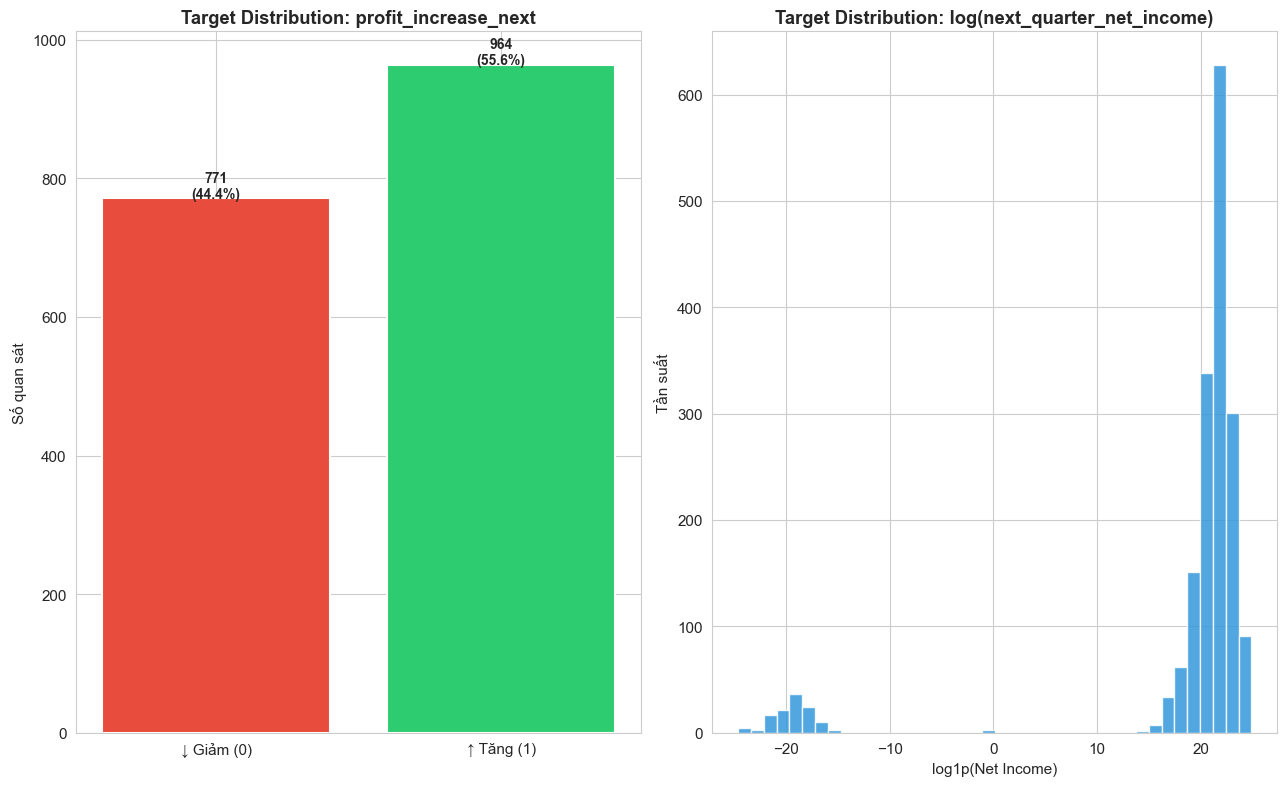

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.2a — Phân phối Target tổng quát
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 8))

# Classification target
vc = df_fe[TARGET_CLS].dropna().value_counts().sort_index()
vc.index = ['↓ Giảm (0)', '↑ Tăng (1)']
bars = axes[0].bar(vc.index, vc.values,
                   color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, f'{val:,}\n({val/vc.sum()*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Target Distribution: profit_increase_next', fontweight='bold')
axes[0].set_ylabel('Số quan sát')

# Regression target
data_r = df_fe[TARGET_REG].dropna()
axes[1].hist(np.sign(data_r) * np.log1p(data_r.abs()),
             bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].set_title('Target Distribution: log(next_quarter_net_income)', fontweight='bold')
axes[1].set_xlabel('log1p(Net Income)')
axes[1].set_ylabel('Tần suất')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

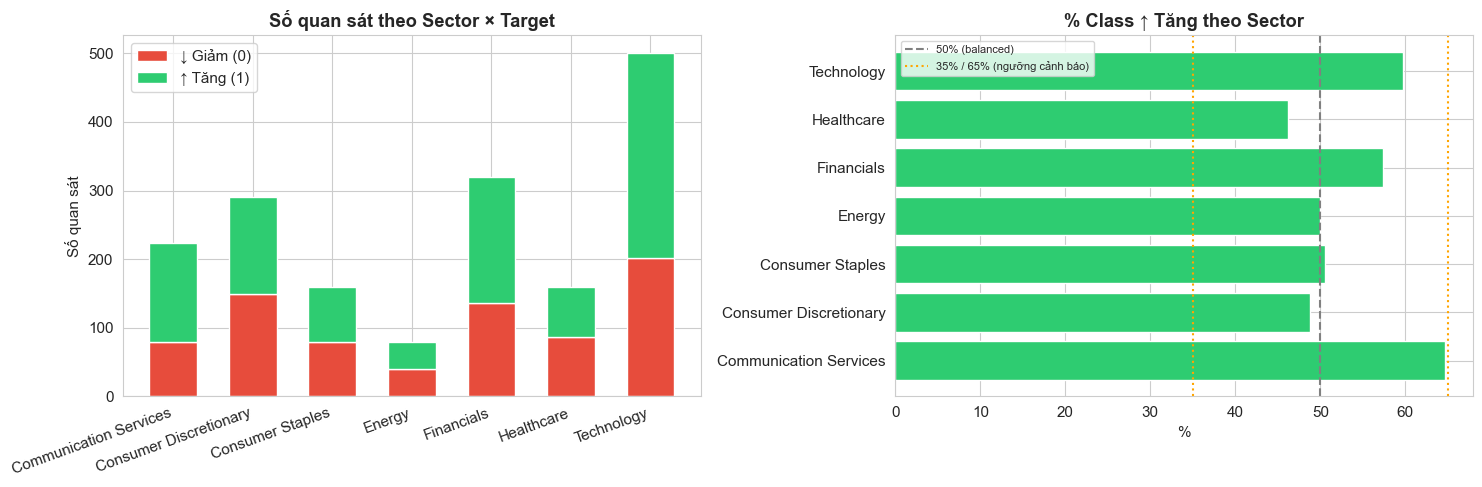


Bảng imbalance theo Sector:


profit_increase_next,↓ Giảm (0),↑ Tăng (1),Total,% Tăng,Ratio 1:0,Imbalance
sector_group,,,,,,
Communication Services,79,145,224,64.7%,1.84,Cân bằng
Consumer Discretionary,149,142,291,48.8%,0.95,Cân bằng
Consumer Staples,79,81,160,50.6%,1.03,Cân bằng
Energy,40,40,80,50.0%,1.00,Cân bằng
Financials,136,183,319,57.4%,1.35,Cân bằng
Healthcare,86,74,160,46.2%,0.86,Cân bằng
Technology,202,299,501,59.7%,1.48,Cân bằng



0/7 sector có class imbalance đáng kể.
   → Xem xét dùng class_weight='balanced' hoặc stratified sampling theo sector.


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.2b — Phân tích Class Imbalance theo Sector
# ─────────────────────────────────────────────────────────────────────────────
if TARGET_CLS in df_fe.columns and "sector_group" in df_fe.columns:
    sector_target = (
        df_fe.dropna(subset=[TARGET_CLS, "sector_group"])
             .groupby(["sector_group", TARGET_CLS])
             .size()
             .unstack(TARGET_CLS, fill_value=0)
             .rename(columns={0: "↓ Giảm (0)", 1: "↑ Tăng (1)"})
    )
    sector_target["Total"]     = sector_target.sum(axis=1)
    sector_target["% Tăng"]    = (sector_target["↑ Tăng (1)"] /
                                    sector_target["Total"] * 100).round(1)
    sector_target["Ratio 1:0"] = (sector_target["↑ Tăng (1)"] /
                                    sector_target["↓ Giảm (0)"].replace(0, np.nan)).round(2)
    sector_target["Imbalance"]  = sector_target["% Tăng"].apply(
        lambda p: "Mất cân bằng" if p < 35 or p > 65 else "Cân bằng"
    )

    # ── Stacked bar chart ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    x = np.arange(len(sector_target))
    w = 0.6
    axes[0].bar(x, sector_target["↓ Giảm (0)"], width=w,
                color="#e74c3c", label="↓ Giảm (0)", edgecolor="white")
    axes[0].bar(x, sector_target["↑ Tăng (1)"], width=w,
                bottom=sector_target["↓ Giảm (0)"],
                color="#2ecc71", label="↑ Tăng (1)", edgecolor="white")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(sector_target.index, rotation=20, ha="right")
    axes[0].set_title("Số quan sát theo Sector × Target", fontweight="bold")
    axes[0].set_ylabel("Số quan sát")
    axes[0].legend()

    # ── % Tăng per sector ────────────────────────────────────────────────────
    bar_colors = ["#e74c3c" if (p < 35 or p > 65) else "#2ecc71"
                  for p in sector_target["% Tăng"]]
    axes[1].barh(sector_target.index, sector_target["% Tăng"],
                 color=bar_colors, edgecolor="white")
    axes[1].axvline(50, color="gray", linestyle="--", linewidth=1.5,
                    label="50% (balanced)")
    axes[1].axvline(35, color="orange", linestyle=":", linewidth=1.5,
                    label="35% / 65% (ngưỡng cảnh báo)")
    axes[1].axvline(65, color="orange", linestyle=":", linewidth=1.5)
    axes[1].set_title("% Class ↑ Tăng theo Sector", fontweight="bold")
    axes[1].set_xlabel("%")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # ── Bảng tóm tắt ────────────────────────────────────────────────────────
    print("\nBảng imbalance theo Sector:")
    display(sector_target.style
        .map(lambda v: "background-color: #ffcccc" if v == "Mất cân bằng" else
                            "background-color: #d5f5e3",
                  subset=["Imbalance"])
        .format({"% Tăng": "{:.1f}%", "Ratio 1:0": "{:.2f}"})
        .set_caption("Class Imbalance theo Sector (đỏ = cần xử lý)"))

    n_imb = (sector_target["Imbalance"] == "Mất cân bằng").sum()
    print(f"\n{n_imb}/{len(sector_target)} sector có class imbalance đáng kể.")
    print("   → Xem xét dùng class_weight='balanced' hoặc stratified sampling theo sector.")
else:
    missing = []
    if TARGET_CLS not in df_fe.columns:
        missing.append(f"TARGET_CLS='{TARGET_CLS}'")
    if "sector_group" not in df_fe.columns:
        missing.append("'sector_group'")
        avail_sectors = [c for c in df_fe.columns if "sector" in c.lower()]
        print(f"   → Cột sector hiện có trong df_processed: {avail_sectors}")
        print(f"   → Kiểm tra lại tên cột sector_group trong file 02_preprocessing.ipynb")
    print(f"⚠️  Không tìm thấy: {', '.join(missing)} trong df_fe.")
    print(f"   Các cột hiện có (20 đầu): {df_fe.columns.tolist()[:20]}")


### **5.3 Kiểm tra hiệu quả Pipeline (Outlier + Correlation)**

Hai kiểm tra sau xác nhận pipeline xử lý đúng hướng:
1. **Before/After Transform** — skewness giảm sau Sign-Log → outlier đã được nén
2. **Correlation heatmap processed** — cấu trúc tương quan có thay đổi sau feature engineering không?


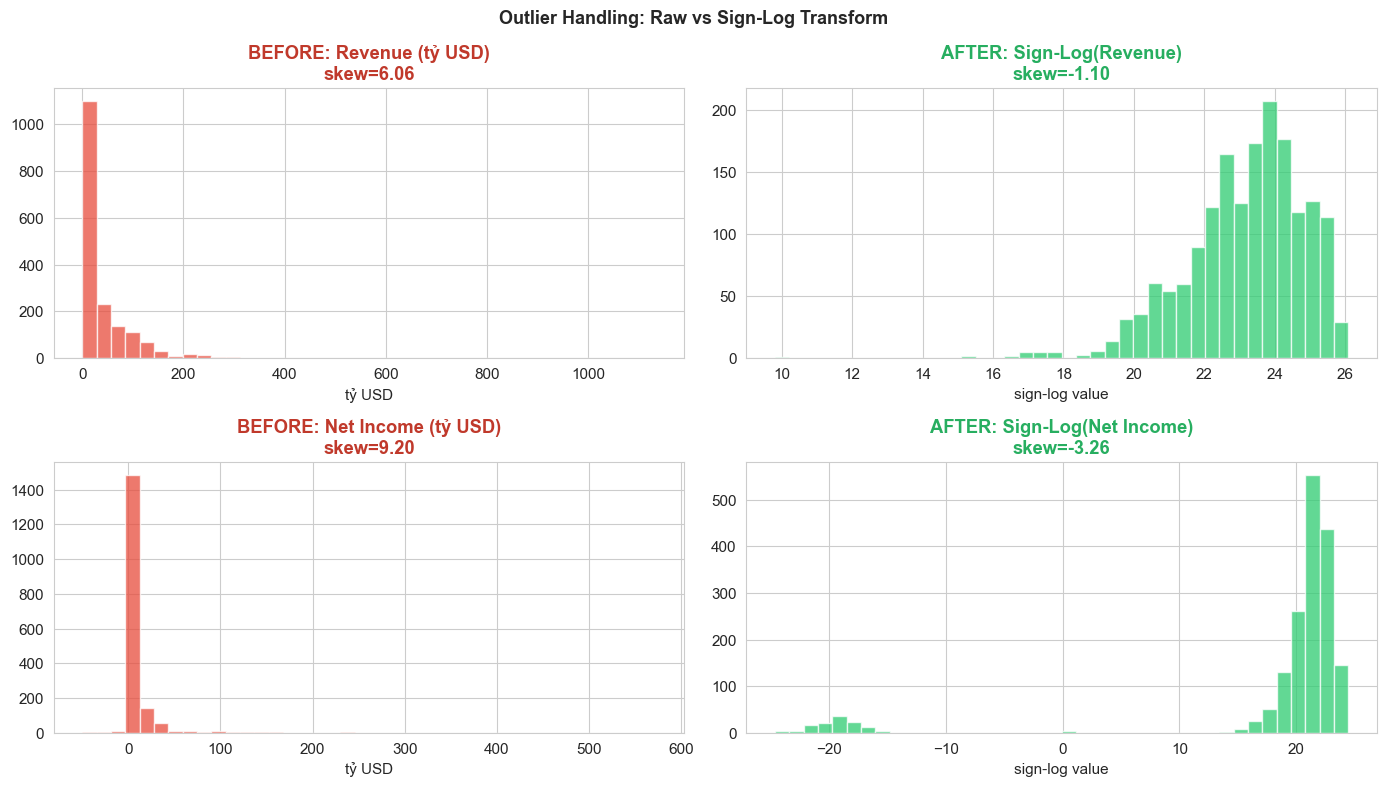

In [23]:
# So sánh phân phối raw vs log-transformed (processed)
# ── Tự động tìm tên cột đúng (xử lý cả camelCase và lowercase) ──────────────
def find_col(df, candidates):
    """Tìm tên cột trong df, không phân biệt hoa thường."""
    col_lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in col_lower:
            return col_lower[c.lower()]
    return None

raw_rev_col  = find_col(df_raw, ["totalRevenue", "totalrevenue", "total_revenue"])
raw_ni_col   = find_col(df_raw, ["netIncome",    "netincome",    "net_income"])
proc_rev_col = find_col(df_processed, ["log_totalrevenue", "log_total_revenue"])
proc_ni_col  = find_col(df_processed, ["log_netincome",    "log_net_income"])

# Báo trước để tránh visualization bị skip âm thầm
assert raw_rev_col,  f"Không tìm thấy cột Revenue trong df_raw. Columns: {df_raw.columns.tolist()[:8]}"
assert raw_ni_col,   f"Không tìm thấy cột NetIncome trong df_raw."
assert proc_rev_col, f"Không tìm thấy log_totalrevenue trong df_processed. Columns: {[c for c in df_processed.columns if 'rev' in c.lower()]}"
assert proc_ni_col,  f"Không tìm thấy log_netincome trong df_processed."

compare_cols = [
    (raw_rev_col,  proc_rev_col, "Revenue"),
    (raw_ni_col,   proc_ni_col,  "Net Income"),
]

fig, axes = plt.subplots(len(compare_cols), 2,
                          figsize=(14, 4 * len(compare_cols)), squeeze=False)

for i, (raw_col, log_col, name) in enumerate(compare_cols):
    ax_b = axes[i, 0]
    ax_a = axes[i, 1]

    before = df_raw[raw_col].dropna()
    after  = df_processed[log_col].dropna()

    ax_b.hist(before / 1e9, bins=40, color="#e74c3c", alpha=0.75, edgecolor="white")
    ax_b.set_title(f"BEFORE: {name} (tỷ USD)\nskew={before.skew():.2f}",
                   fontweight="bold", color="#c0392b")
    ax_b.set_xlabel("tỷ USD")

    ax_a.hist(after, bins=40, color="#2ecc71", alpha=0.75, edgecolor="white")
    ax_a.set_title(f"AFTER: Sign-Log({name})\nskew={after.skew():.2f}",
                   fontweight="bold", color="#27ae60")
    ax_a.set_xlabel("sign-log value")

plt.suptitle("Outlier Handling: Raw vs Sign-Log Transform",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outlier_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

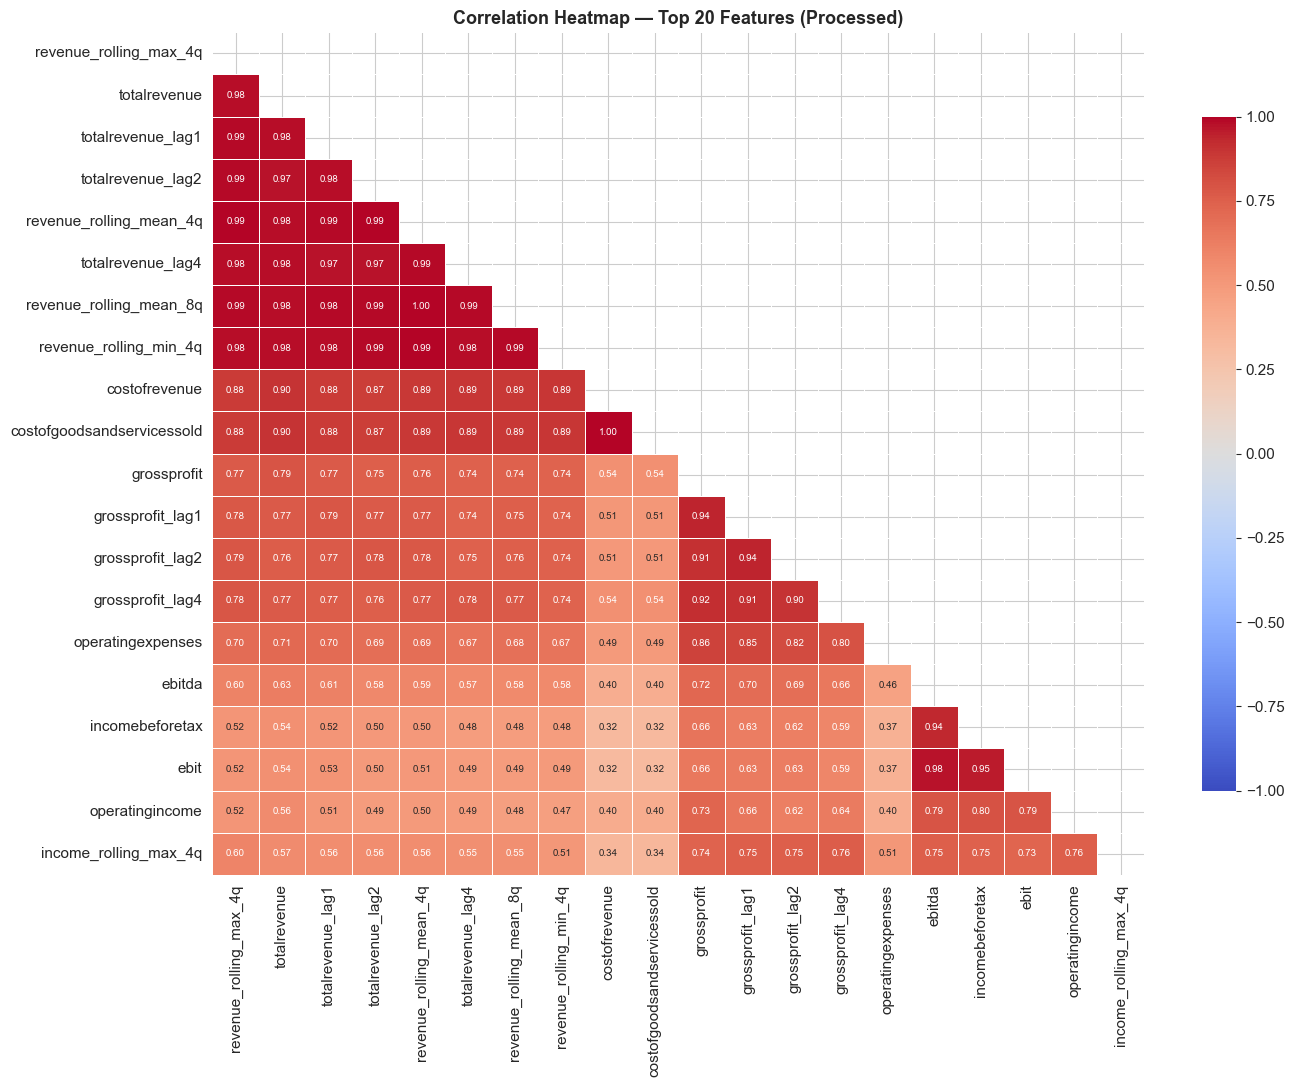

Max |corr| (off-diagonal): 0.997


In [24]:
# Correlation Heatmap (Processed)
# Loại bỏ cột không phải numeric và cột meta
meta_cols = [DATE_COL_PROCESSED, GROUP_COL, "sector_group", "currency",
             TARGET_CLS, TARGET_REG, "year"]
num_cols = [c for c in df_processed.select_dtypes(include=np.number).columns
            if c not in meta_cols]

# Lấy top 20 cột theo variance để heatmap rõ hơn
top20 = df_processed[num_cols].var().nlargest(20).index.tolist()
corr = df_processed[top20].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, vmin=-1, vmax=1,
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap — Top 20 Features (Processed)",
          fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Max |corr| (off-diagonal): {corr[corr < 1].abs().max().max():.3f}")

### **5.4 Phân phối Feature theo Symbol (Processed)**

Sau pipeline, kiểm tra nhanh xem phân phối của các feature đã được log-transform có còn chênh lệch lớn giữa các công ty không — làm căn cứ xác nhận **group-wise normalization** đã phát huy tác dụng.

- Box hẹp và đều hơn so với raw (mục 4.6) → pipeline hiệu quả
- Nếu vẫn còn outlier rõ → cân nhắc thêm bước robust scaling theo symbol


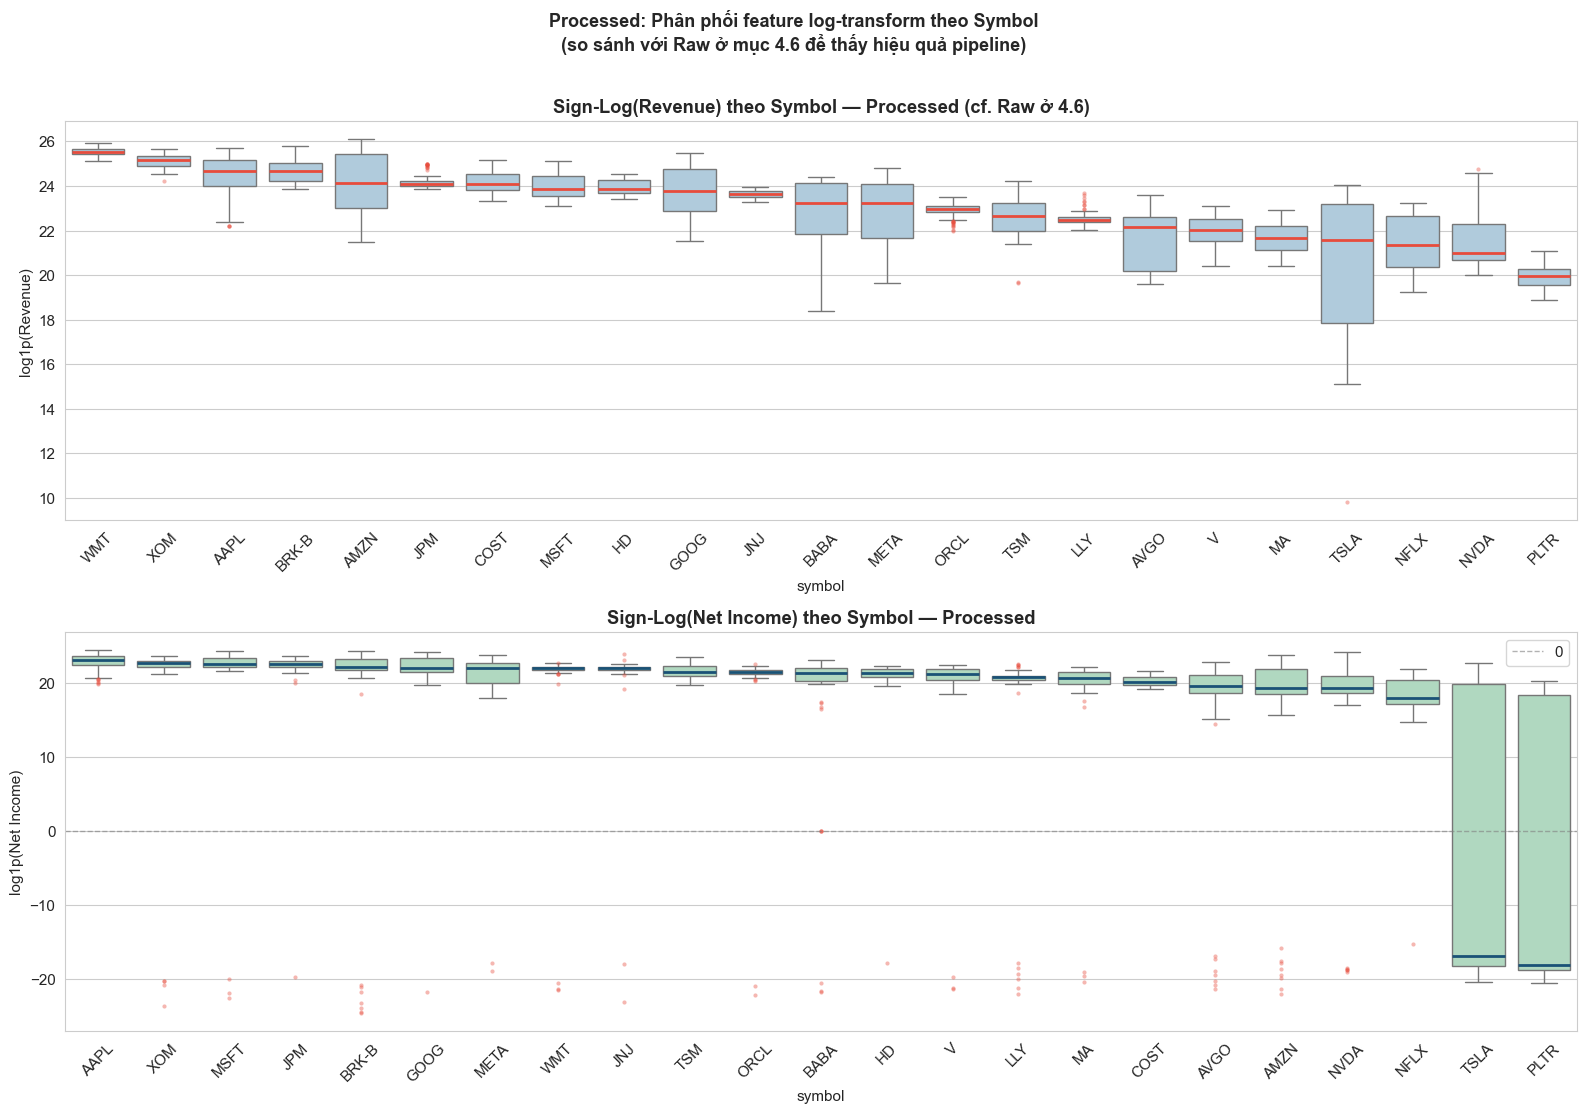

,n_outlier,% outlier
column,,
log_totalrevenue,29,1.7%
log_netincome,151,8.7%


In [25]:
# ── 5.4 Boxplot log_totalrevenue & log_netincome theo Symbol (Processed) ──────
rev_log_col = find_col(df_processed, ["log_totalrevenue", "log_total_revenue"])
ni_log_col  = find_col(df_processed, ["log_netincome",    "log_net_income"])

if rev_log_col is None or ni_log_col is None:
    print("⚠️  Không tìm thấy cột log_totalrevenue hoặc log_netincome trong df_processed.")
    print(f"   Các cột log hiện có: {[c for c in df_processed.columns if 'log' in c.lower()]}")
else:
    fig, axes = plt.subplots(2, 1, figsize=(16, 11))

    order_rev_p = (df_processed.groupby("symbol")[rev_log_col].median()
                               .sort_values(ascending=False).index.tolist())
    sns.boxplot(
        data=df_processed, x="symbol", y=rev_log_col, ax=axes[0], order=order_rev_p,
        color="#a9cce3",
        medianprops=dict(color="#e74c3c", linewidth=2),
        flierprops=dict(marker="o", markersize=3, alpha=0.4,
                        markerfacecolor="#e74c3c", markeredgecolor="none")
    )
    axes[0].set_title(f"Sign-Log(Revenue) theo Symbol — Processed (cf. Raw ở 4.6)",
                      fontweight="bold")
    axes[0].set_ylabel("log1p(Revenue)")
    axes[0].tick_params(axis="x", rotation=45)

    order_ni_p = (df_processed.groupby("symbol")[ni_log_col].median()
                              .sort_values(ascending=False).index.tolist())
    sns.boxplot(
        data=df_processed, x="symbol", y=ni_log_col, ax=axes[1], order=order_ni_p,
        color="#a9dfbf",
        medianprops=dict(color="#1a5276", linewidth=2),
        flierprops=dict(marker="o", markersize=3, alpha=0.4,
                        markerfacecolor="#e74c3c", markeredgecolor="none")
    )
    axes[1].set_title("Sign-Log(Net Income) theo Symbol — Processed", fontweight="bold")
    axes[1].set_ylabel("log1p(Net Income)")
    axes[1].axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="0")
    axes[1].legend()
    axes[1].tick_params(axis="x", rotation=45)

    plt.suptitle("Processed: Phân phối feature log-transform theo Symbol\n"
                 "(so sánh với Raw ở mục 4.6 để thấy hiệu quả pipeline)",
                 fontweight="bold", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("processed_symbol_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Thống kê nhanh: còn bao nhiêu outlier IQR sau transform?
    outlier_after = []
    for col in [rev_log_col, ni_log_col]:
        s = df_processed[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        n_out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
        outlier_after.append({"column": col, "n_outlier": n_out,
                               "% outlier": round(n_out / len(s) * 100, 1)})
    display(pd.DataFrame(outlier_after).set_index("column")
              .style.format({"% outlier": "{:.1f}%"})
              .set_caption("Outlier còn lại sau Sign-Log Transform (IQR rule)"))


### **5.5 Time-series Revenue & YoY Growth**


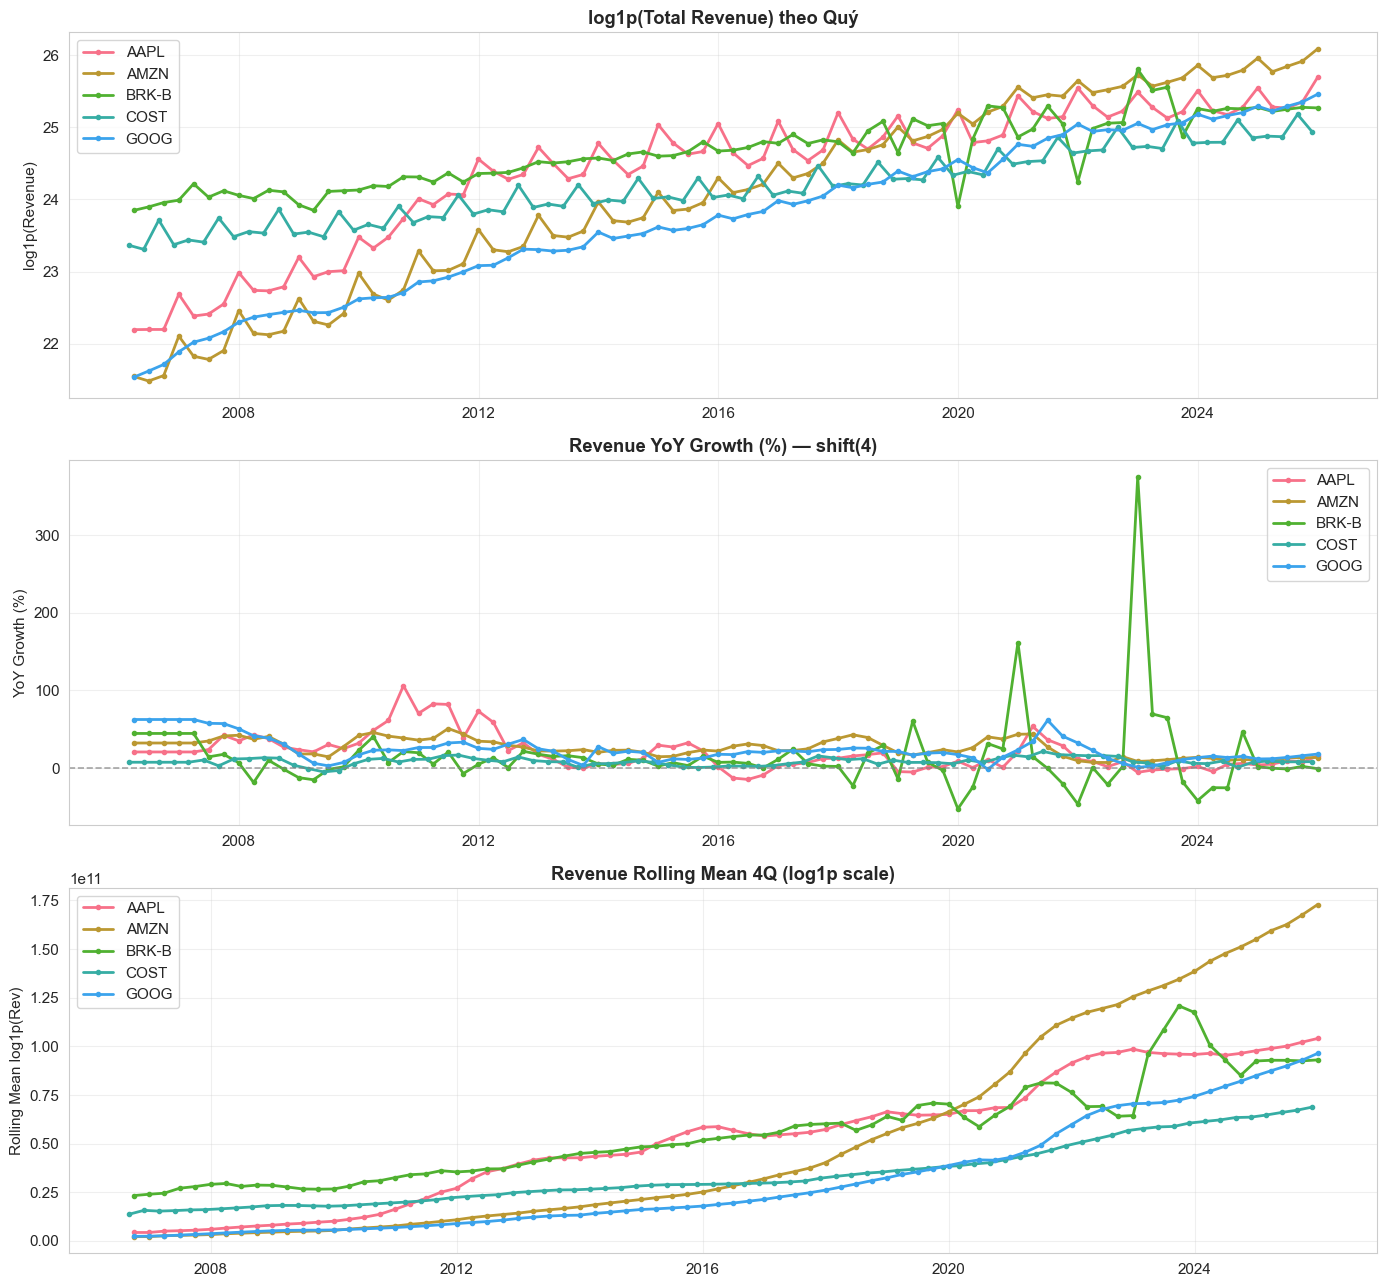

In [26]:
top_symbols = df_fe['symbol'].value_counts().head(5).index.tolist()
df_plot = df_fe[df_fe['symbol'].isin(top_symbols)].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# ── Revenue (log scale) ───────────────────────────────────────
for sym in top_symbols:
    d = df_plot[df_plot['symbol'] == sym].sort_values(DATE_COL_PROCESSED)
    if 'log_totalrevenue' in d.columns:
        axes[0].plot(d[DATE_COL_PROCESSED], d['log_totalrevenue'],
                     marker='o', markersize=3, linewidth=2, label=sym)
axes[0].set_title('log1p(Total Revenue) theo Quý', fontweight='bold')
axes[0].set_ylabel('log1p(Revenue)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── YoY Revenue Growth ────────────────────────────────────────
for sym in top_symbols:
    d = df_plot[df_plot['symbol'] == sym].sort_values(DATE_COL_PROCESSED)
    if 'revenue_yoy_growth' in d.columns:
        axes[1].plot(d[DATE_COL_PROCESSED], d['revenue_yoy_growth'] * 100,
                     marker='o', markersize=3, linewidth=2, label=sym)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
axes[1].set_title('Revenue YoY Growth (%) — shift(4)', fontweight='bold')
axes[1].set_ylabel('YoY Growth (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Rolling Revenue Trend (4q mean) ──────────────────────────
for sym in top_symbols:
    d = df_plot[df_plot['symbol'] == sym].sort_values(DATE_COL_PROCESSED)
    if 'revenue_rolling_mean_4q' in d.columns:
        axes[2].plot(d[DATE_COL_PROCESSED], d['revenue_rolling_mean_4q'],
                     marker='o', markersize=3, linewidth=2, label=sym)
axes[2].set_title('Revenue Rolling Mean 4Q (log1p scale)', fontweight='bold')
axes[2].set_ylabel('Rolling Mean log1p(Rev)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('timeseries_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### **5.6 Phân phối theo ngành**


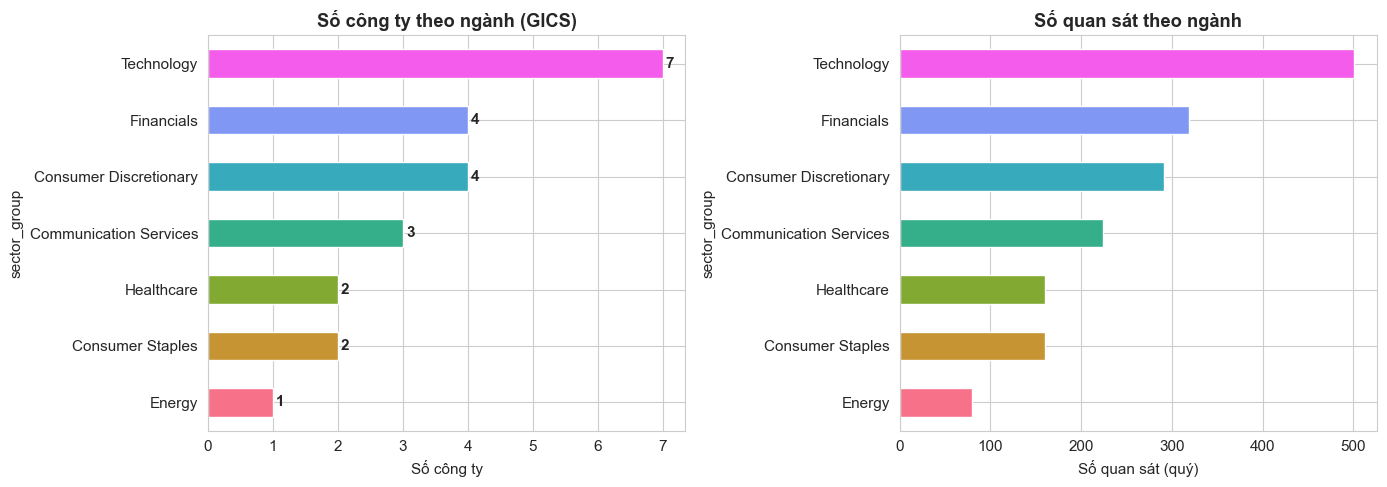

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ind_companies = (
    df_fe.groupby('sector_group')['symbol'].nunique()
         .sort_values(ascending=True)
)
colors = sns.color_palette('husl', len(ind_companies))

ind_companies.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Số công ty theo ngành (GICS)', fontweight='bold')
axes[0].set_xlabel('Số công ty')
for i, v in enumerate(ind_companies.values):
    axes[0].text(v + 0.05, i, str(v), va='center', fontweight='bold')

ind_obs = df_fe['sector_group'].value_counts().sort_values(ascending=True)
ind_obs.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Số quan sát theo ngành', fontweight='bold')
axes[1].set_xlabel('Số quan sát (quý)')

plt.tight_layout()
plt.savefig('sector_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## **6. Summary**


In [28]:
print("=" * 65)
print("EDA SUMMARY")
print("=" * 65)
print(f"  Raw data       : {df_raw.shape[0]:>6,} rows × {df_raw.shape[1]:>3} cols")
print(f"  Processed data : {df_processed.shape[0]:>6,} rows × {df_processed.shape[1]:>3} cols")
print(f"  Symbols        : {df_processed[GROUP_COL].nunique()} công ty")
print(f"  Date range     : {df_processed[DATE_COL_PROCESSED].min().date()} → {df_processed[DATE_COL_PROCESSED].max().date()}")

if TARGET_CLS in df_processed.columns:
    vc = df_processed[TARGET_CLS].value_counts(normalize=True)
    print(f"\n  Target ({TARGET_CLS}):")
    for k, v in vc.sort_index().items():
        label = "↑ Tăng" if k == 1 else "↓ Giảm"
        print(f"    {label} ({k}): {v*100:.1f}%")

print("\n" + "=" * 65)
print("KEY INSIGHTS")
print("=" * 65)

# ── 1. Skewness raw vs sau transform ─────────────────────────────────────────
raw_rev = find_col(df_raw, ["totalRevenue", "totalrevenue"])
proc_rev = find_col(df_processed, ["log_totalrevenue", "log_total_revenue"])
if raw_rev and proc_rev:
    sk_before = df_raw[raw_rev].skew()
    sk_after  = df_processed[proc_rev].skew()
    print(f"\n  [1] Skewness (Revenue):")
    print(f"      Raw       : {sk_before:+.2f}  → phân phối lệch {'mạnh' if abs(sk_before)>1 else 'nhẹ'}")
    print(f"      Sign-Log  : {sk_after:+.2f}  → {'cải thiện rõ rệt ✅' if abs(sk_after) < abs(sk_before) else '⚠️ chưa cải thiện'}")

# ── 2. Outlier trước/sau ──────────────────────────────────────────────────────
if raw_rev:
    s = df_raw[raw_rev].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_out_raw = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    print(f"\n  [2] Outlier (Revenue, IQR rule):")
    print(f"      Raw      : {n_out_raw} điểm ({n_out_raw/len(s)*100:.1f}%)")
if proc_rev:
    s2 = df_processed[proc_rev].dropna()
    q1b, q3b = s2.quantile(0.25), s2.quantile(0.75)
    iqrb = q3b - q1b
    n_out_proc = ((s2 < q1b - 1.5*iqrb) | (s2 > q3b + 1.5*iqrb)).sum()
    print(f"      Processed: {n_out_proc} điểm ({n_out_proc/len(s2)*100:.1f}%) → {'giảm ✅' if n_out_proc < n_out_raw else '⚠️ kiểm tra lại'}")

# ── 3. Correlation sau xử lý ─────────────────────────────────────────────────
meta_cols_s = [DATE_COL_PROCESSED, GROUP_COL, "sector_group", "currency",
               TARGET_CLS, TARGET_REG, "year"]
num_cols_s = [c for c in df_processed.select_dtypes(include=np.number).columns
              if c not in meta_cols_s]
if len(num_cols_s) >= 2:
    top20_s = df_processed[num_cols_s].var().nlargest(20).index.tolist()
    corr_proc = df_processed[top20_s].corr().abs()
    max_corr = corr_proc[corr_proc < 1].max().max()
    n_high_corr = (corr_proc.where(np.triu(np.ones_like(corr_proc, dtype=bool), k=1))
                             .stack() > 0.85).sum()
    print(f"\n  [3] Correlation (Processed, top 20 features):")
    print(f"      Max |corr| off-diagonal : {max_corr:.3f}")
    print(f"      Cặp > 0.85             : {n_high_corr} {'→ còn multicollinearity, xem xét VIF ⚠️' if n_high_corr > 0 else '→ đã xử lý tốt ✅'}")

# ── 4. Time-series gap ────────────────────────────────────────────────────────
try:
    n_gap_warn = (df_gaps["gap_ok"] == "⚠️").sum()
    print(f"\n  [4] Time-Series Gap: {n_gap_warn}/{len(df_gaps)} công ty có gap > 100 ngày")
    print(f"      {'→ shift(4) an toàn ✅' if n_gap_warn == 0 else '→ cần kiểm tra trước khi dùng shift/rolling ⚠️'}")
except NameError:
    print("\n  [4] Time-Series Gap: chạy mục 4.7 để xem kết quả.")

# ── 5. Class imbalance ────────────────────────────────────────────────────────
if TARGET_CLS in df_processed.columns:
    ratio = df_processed[TARGET_CLS].value_counts(normalize=True)
    majority = ratio.max()
    print(f"\n  [5] Class Imbalance ({TARGET_CLS}): {majority*100:.1f}% / {(1-majority)*100:.1f}%")
    if majority > 0.65:
        print(f"      → Mất cân bằng đáng kể, cân nhắc class_weight='balanced' hoặc SMOTE ⚠️")
    else:
        print(f"      → Tương đối cân bằng ✅")

print("\n" + "=" * 65)
print("📁 Charts saved:")
for fname in ["outlier_before_after.png", "correlation_heatmap.png",
              "timeseries_visualization.png", "sector_distribution.png",
              "target_distribution.png", "processed_symbol_distribution.png"]:
    exists = "✅" if Path(fname).exists() else "❌"
    print(f"  {exists} {fname}")
print("=" * 65)


EDA SUMMARY
  Raw data       :  1,762 rows ×  28 cols
  Processed data :  1,735 rows × 117 cols
  Symbols        : 23 công ty
  Date range     : 2006-01-31 → 2025-12-31

  Target (profit_increase_next):
    ↓ Giảm (0.0): 44.4%
    ↑ Tăng (1.0): 55.6%

KEY INSIGHTS

  [1] Skewness (Revenue):
      Raw       : +6.06  → phân phối lệch mạnh
      Sign-Log  : -1.10  → cải thiện rõ rệt ✅

  [2] Outlier (Revenue, IQR rule):
      Raw      : 129 điểm (7.3%)
      Processed: 29 điểm (1.7%) → giảm ✅

  [3] Correlation (Processed, top 20 features):
      Max |corr| off-diagonal : 0.997
      Cặp > 0.85             : 55 → còn multicollinearity, xem xét VIF ⚠️

  [4] Time-Series Gap: 1/23 công ty có gap > 100 ngày
      → cần kiểm tra trước khi dùng shift/rolling ⚠️

  [5] Class Imbalance (profit_increase_next): 55.6% / 44.4%
      → Tương đối cân bằng ✅

📁 Charts saved:
  ✅ outlier_before_after.png
  ✅ correlation_heatmap.png
  ✅ timeseries_visualization.png
  ✅ sector_distribution.png
  ✅ target_